### 1. Problem Statement:
DoorDash wants to accurately predict delivery duration (in seconds) — the total time between when an order is created (created_at) and when it is delivered (actual_delivery_time).

### 2. Business Understanding
Problem Definition:

Predict total delivery duration (seconds) → (actual_delivery_time − created_at)

Used for: Real-time ETA prediction in customer app, driver app, restaurant portal, and internal ops.

### Predicting delivery time is not just ML — it directly impacts:

Customer satisfaction

Operational efficiency

Cost optimization

Dynamic pricing

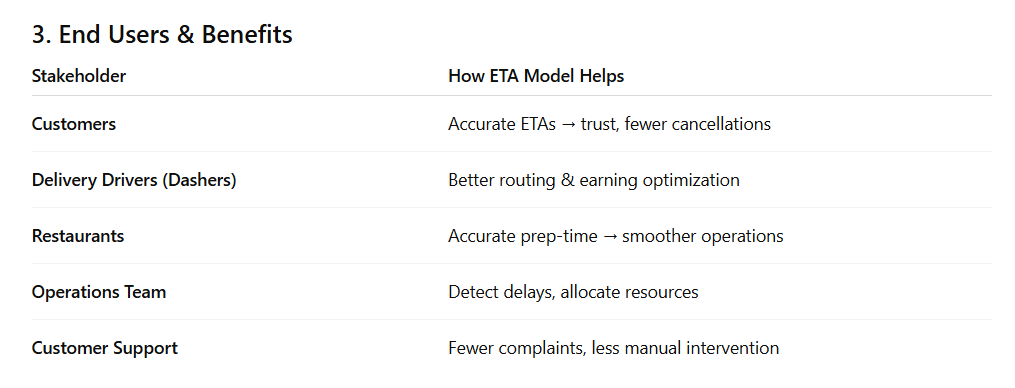!

### 4.Business Value

✅ Higher customer satisfaction & retention

✅ Fewer refunds / escalations

✅ Lower operational waste (better staffing & routing)

✅ Competitive advantage in the food-delivery market

Impact of Wrong Predictions

Over-predict (ETA too slow) → user abandons order → lost revenue

Under-predict (ETA too fast) → frustration, bad reviews

Large errors (>30 mins) → breaks customer trust

📌 Key Insight: ETA systems prioritize accuracy over interpretability.

Model Inputs (Existing Sub-Models)
These ML features come from DoorDash’s other internal models:

estimated_order_place_duration → Time for restaurant to receive order from doordash platform.

estimated_store_to_consumer_driving_duration → expected travel time

Our model learns to combine these + marketplace signals to predict final ETA.



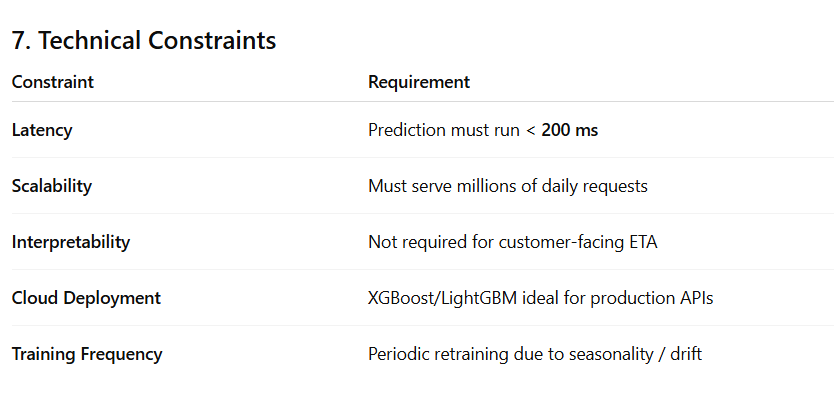!
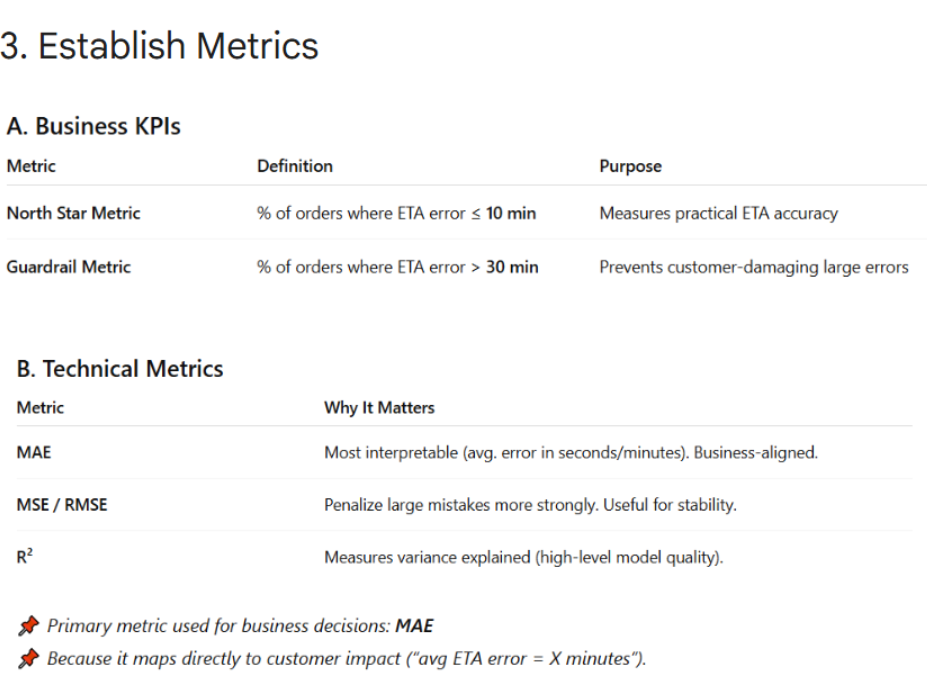!


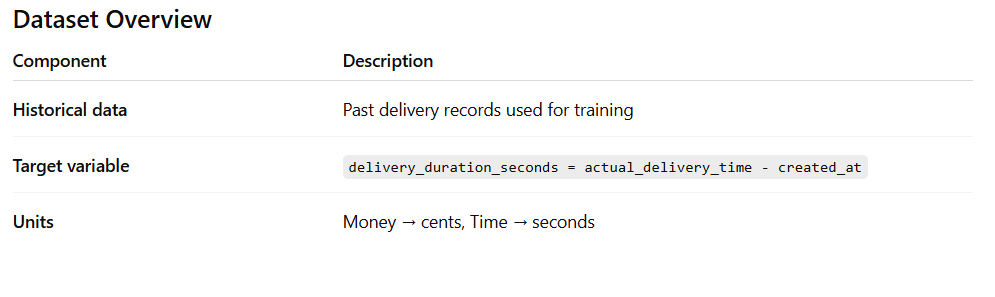!
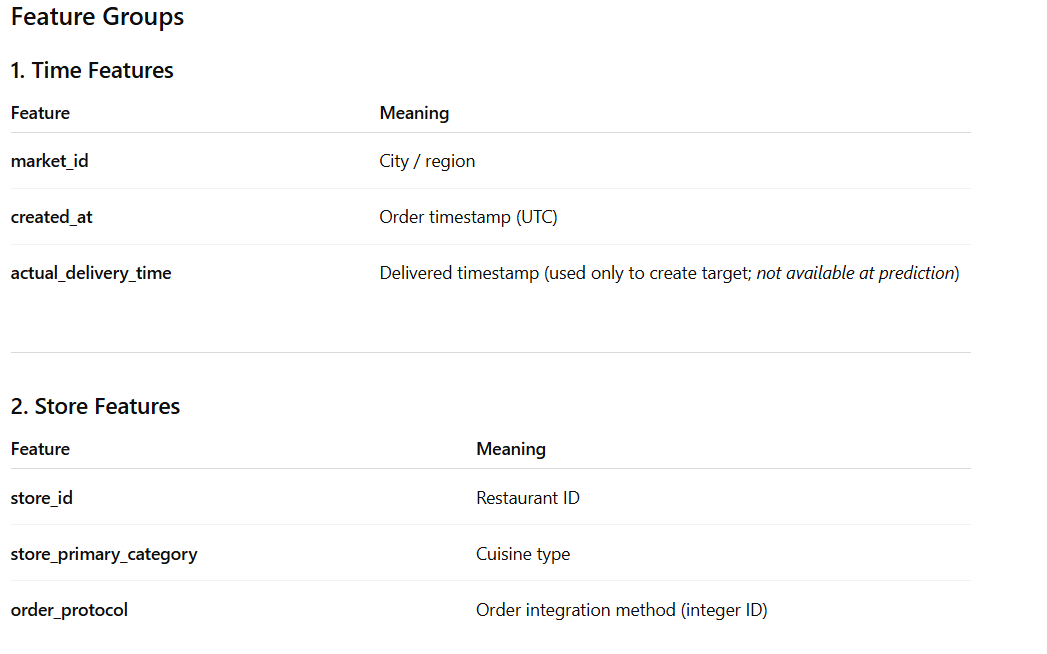!

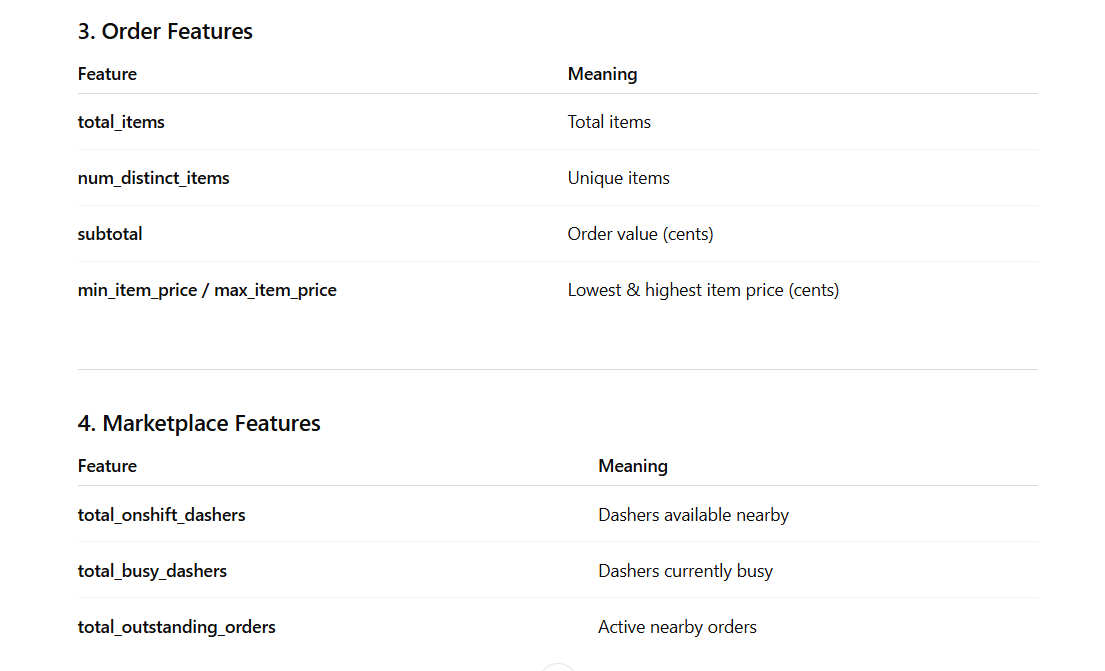

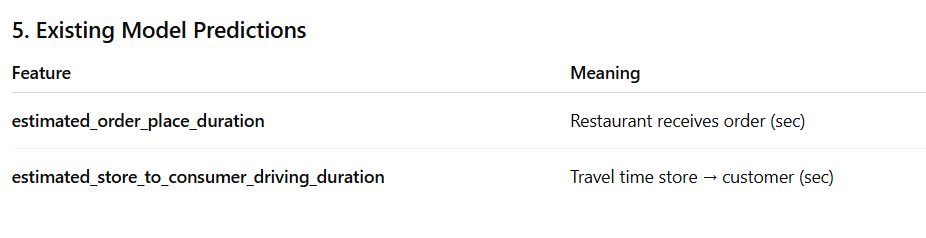

In [1]:
#step 1 import and load data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# imputer and encoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
# models
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
# evaluation metrics
from sklearn.metrics import mean_absolute_error ,  mean_squared_error, r2_score
#Cross Validation 
from sklearn.model_selection import RandomizedSearchCV , TimeSeriesSplit
# shap
import shap


In [2]:
#!pip install shap

In [3]:

#Load data
df = pd.read_csv("E:\ml\historical_data.csv")
     

In [4]:
df.head()

,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,estimated_store_to_consumer_driving_duration
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,1845,american,1.0,4,3441,4,557,1239,33.0,14.0,21.0,446,861.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,5477,mexican,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,446,690.0
2,3.0,2015-01-22 20:39:28,2015-01-22 21:09:09,5477,NaN,1.0,1,1900,1,1900,1900,1.0,0.0,0.0,446,690.0
3,3.0,2015-02-03 21:21:45,2015-02-03 22:13:00,5477,NaN,1.0,6,6900,5,600,1800,1.0,1.0,2.0,446,289.0
4,3.0,2015-02-15 02:40:36,2015-02-15 03:20:26,5477,NaN,1.0,3,3900,3,1100,1600,6.0,6.0,9.0,446,650.0


In [5]:
df.dtypes

market_id                                       float64
created_at                                       object
actual_delivery_time                             object
store_id                                          int64
store_primary_category                           object
order_protocol                                  float64
total_items                                       int64
subtotal                                          int64
num_distinct_items                                int64
min_item_price                                    int64
max_item_price                                    int64
total_onshift_dashers                           float64
total_busy_dashers                              float64
total_outstanding_orders                        float64
estimated_order_place_duration                    int64
estimated_store_to_consumer_driving_duration    float64
dtype: object

In [6]:
#step 3 check for duplicates
df[df.duplicated()]
df[df.duplicated()].value_counts()

Series([], Name: count, dtype: int64)

In [7]:
#There are NO duplicate rows in your dataframe.
#That’s why it returns an empty Series.

In [8]:
# df.duplicated() This creates a boolean column:
#True → duplicate row
#False → unique row

In [9]:
#Step-4. Create Target Variable
df["created_at"] = pd.to_datetime(df["created_at"])
df["actual_delivery_time"] = pd.to_datetime(df["actual_delivery_time"])
df["delivery_duration_seconds"] = (df["actual_delivery_time"]-df["created_at"]).dt.total_seconds()
df.drop(columns=["actual_delivery_time"],inplace=True)


## Step-5. Basic Checks in given Data
a. target variable(delivery_duration_seconds) is negative

In [10]:
df[(df['delivery_duration_seconds'])<0]

,market_id,created_at,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,estimated_store_to_consumer_driving_duration,delivery_duration_seconds


In [11]:
#no negative target record found


b. sum of internal model-estimated durations is longer than the real delivery time.

In [12]:
df[((df["estimated_order_place_duration"]+df["estimated_store_to_consumer_driving_duration"])>df["delivery_duration_seconds"])]

,market_id,created_at,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,estimated_store_to_consumer_driving_duration,delivery_duration_seconds
862,2.0,2015-01-25 21:59:08,1904,sandwich,2.0,1,1195,1,1195,1195,60.0,74.0,51.0,251,218.0,223.0
12580,2.0,2015-02-01 23:28:51,6147,sandwich,2.0,1,0,1,550,550,31.0,27.0,28.0,251,556.0,773.0
19208,2.0,2015-02-06 06:10:39,6865,mexican,5.0,1,699,1,699,699,18.0,20.0,27.0,251,803.0,901.0
22619,2.0,2015-02-07 01:20:38,6127,chinese,3.0,4,2500,3,300,1000,24.0,18.0,17.0,251,661.0,664.0
22642,1.0,2015-02-08 00:45:58,3023,chinese,4.0,1,1192,1,942,942,27.0,23.0,23.0,251,1034.0,1275.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175950,1.0,2015-01-28 04:17:06,2205,mexican,1.0,3,5585,3,1595,2195,26.0,19.0,20.0,446,282.0,607.0
180809,1.0,2015-02-01 04:36:19,1145,pizza,5.0,1,1050,1,1050,1050,31.0,34.0,32.0,251,563.0,646.0
194711,4.0,2015-02-06 22:02:16,1409,thai,5.0,1,825,1,750,750,27.0,23.0,22.0,251,557.0,542.0
195851,2.0,2015-01-30 00:50:39,4862,sandwich,3.0,1,999,1,999,999,55.0,45.0,48.0,251,774.0,762.0


This is not impossible in reality:

Restaurant was faster than expected

Dasher arrived earlier

Driving conditions were better than usual
#### Note: Keep them, unless they are extreme outliers
#### c. total_items should be greater than num_distinct_items for any given order.

In [13]:
df[df['total_items']<df['num_distinct_items']]

,market_id,created_at,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,estimated_store_to_consumer_driving_duration,delivery_duration_seconds



#### d. min_price > max_price

In [14]:
df[(df['min_item_price']>df['max_item_price'])]

,market_id,created_at,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,estimated_store_to_consumer_driving_duration,delivery_duration_seconds
166,6.0,2015-01-31 01:35:23,976,breakfast,2.0,2,1741,2,889,772,NaN,NaN,NaN,251,597.0,2480.0
273,4.0,2015-01-24 03:03:18,5081,mexican,1.0,1,1403,1,1314,1292,129.0,127.0,205.0,251,464.0,3552.0
1144,5.0,2015-01-31 20:10:47,4215,NaN,1.0,1,1289,1,1437,1400,21.0,13.0,19.0,446,198.0,2322.0
1149,5.0,2015-01-30 02:20:58,4215,NaN,1.0,1,1828,1,2031,1935,24.0,21.0,23.0,446,976.0,3224.0
1189,6.0,2015-02-10 22:37:10,4476,soup,3.0,2,1926,2,674,657,NaN,NaN,NaN,251,966.0,3480.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196848,4.0,2015-02-07 20:52:15,6964,pizza,3.0,1,3174,1,1513,1403,38.0,31.0,32.0,251,680.0,2203.0
197032,4.0,2015-02-16 02:34:06,1409,vietnamese,5.0,2,2086,1,904,878,85.0,77.0,152.0,251,409.0,2796.0
197143,4.0,2015-02-03 02:57:44,1409,vietnamese,5.0,2,2082,2,1020,928,88.0,87.0,150.0,251,390.0,2628.0
197385,1.0,2015-01-30 19:24:55,2956,fast,4.0,1,1142,1,737,701,22.0,19.0,32.0,251,347.0,2306.0



It is impossible for the minimum price to be greater than the maximum price → clear data entry or system error.

Such records introduce noise into the model.

Given only 0.4%, dropping is safe.


#### e. price > subtotal inconsistencies

In [15]:
df[~((df["min_item_price"]<=df["subtotal"]) & (df["max_item_price"]<=df["subtotal"]))]

,market_id,created_at,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,estimated_store_to_consumer_driving_duration,delivery_duration_seconds
592,2.0,2015-02-02 20:47:42,4062,barbecue,3.0,1,1076,1,1141,1236,36.0,34.0,40.0,251,661.0,2054.0
790,1.0,2015-01-29 02:59:28,132,fast,4.0,3,1003,3,-86,1066,24.0,29.0,38.0,251,721.0,2681.0
1070,4.0,2015-01-25 17:28:32,517,american,3.0,7,0,7,295,1225,6.0,22.0,8.0,251,241.0,2068.0
1144,5.0,2015-01-31 20:10:47,4215,NaN,1.0,1,1289,1,1437,1400,21.0,13.0,19.0,446,198.0,2322.0
1149,5.0,2015-01-30 02:20:58,4215,NaN,1.0,1,1828,1,2031,1935,24.0,21.0,23.0,446,976.0,3224.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193944,6.0,2015-01-31 02:42:31,2143,japanese,5.0,1,1131,1,1124,1211,122.0,123.0,234.0,251,412.0,2415.0
194839,6.0,2015-02-12 05:20:30,831,mediterranean,3.0,2,205,2,922,1789,NaN,NaN,NaN,251,646.0,1360.0
195154,2.0,2015-02-07 02:08:48,3194,pizza,3.0,1,3095,1,3306,3313,62.0,43.0,78.0,251,740.0,4018.0
195912,2.0,2015-02-16 19:16:42,4862,sandwich,5.0,1,782,1,1011,1071,36.0,39.0,61.0,251,596.0,3980.0


Subtotal must be ≥ highest individual item price. These also indicate broken or partial order logs.

Since only 0.3%, removing them is fine.

In [16]:
df[df["total_busy_dashers"]>df["total_onshift_dashers"]]

,market_id,created_at,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,estimated_store_to_consumer_driving_duration,delivery_duration_seconds
1,2.0,2015-02-10 21:49:25,5477,mexican,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,446,690.0,4024.0
7,3.0,2015-02-12 03:03:35,5477,NaN,1.0,4,4850,4,750,1800,7.0,8.0,7.0,446,626.0,1965.0
14,1.0,2015-02-12 03:36:46,2841,italian,1.0,1,1525,1,1525,1525,5.0,6.0,8.0,446,795.0,2273.0
18,1.0,2015-01-31 04:35:54,2841,italian,1.0,2,3150,2,1425,1725,4.0,9.0,12.0,446,548.0,4296.0
20,1.0,2015-01-31 23:45:12,4139,mexican,1.0,5,1285,3,150,400,12.0,13.0,11.0,446,424.0,1733.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197411,1.0,2015-02-02 17:50:23,2956,fast,4.0,2,1297,2,369,639,5.0,6.0,7.0,251,186.0,1354.0
197412,1.0,2015-02-10 23:43:08,2956,fast,4.0,1,674,1,345,345,10.0,11.0,12.0,251,706.0,3856.0
197418,1.0,2015-01-30 20:50:23,2956,fast,4.0,2,1528,2,639,729,26.0,29.0,34.0,251,791.0,5655.0
197422,1.0,2015-01-31 19:48:15,2956,fast,4.0,7,2445,3,145,585,23.0,24.0,24.0,251,608.0,2364.0


 Why total_busy_dashers > total_onshift_dashers Happens
 Even though busy dashers should be a subset of on-shift dashers, this condition is normal in DoorDash marketplace data..

Why this happens
image.png

How to handle
✔️ Do not drop these rows (often ~20% of data).

✔️ Keep the data as-is — this is normal operational noise.

Why keep them?
These “inconsistencies” reflect:
Demand surges

Dasher shortages

Marketplace pressure

Longer delivery times

➡️ They improve model accuracy rather than hurting it.
This indicates potential data quality issues such as timing mismatches, duplicate records, or inconsistent status updates across systems.

#### g. Negative Values Check

In [17]:
num_columns = ['market_id', 'store_id',
       'order_protocol', 'total_items', 'subtotal', 'num_distinct_items',
       'min_item_price', 'max_item_price', 'total_onshift_dashers',
       'total_busy_dashers', 'total_outstanding_orders',
       'estimated_order_place_duration',
       'estimated_store_to_consumer_driving_duration',
       'delivery_duration_seconds']
negative_rows = (df[num_columns]<0).any(axis=1)
negative_columns = (df[num_columns]<0).any(axis=0)
df[negative_rows]



,market_id,created_at,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,estimated_store_to_consumer_driving_duration,delivery_duration_seconds
790,1.0,2015-01-29 02:59:28,132,fast,4.0,3,1003,3,-86,1066,24.0,29.0,38.0,251,721.0,2681.0
1351,2.0,2015-02-06 05:26:55,6740,fast,4.0,35,1786,4,-1,488,33.0,36.0,52.0,251,587.0,2926.0
4989,1.0,2015-02-18 00:36:21,1811,smoothie,2.0,2,1940,1,840,856,11.0,14.0,-2.0,251,460.0,2167.0
6034,3.0,2015-02-14 01:48:58,90,american,1.0,2,3538,2,1238,1606,-2.0,2.0,10.0,446,266.0,4275.0
7997,1.0,2015-02-08 15:41:45,6172,sandwich,3.0,1,1514,1,1116,1063,1.0,-1.0,3.0,251,650.0,3196.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188786,3.0,2015-02-11 14:41:00,2360,american,1.0,1,1345,1,957,1113,2.0,-2.0,23.0,446,609.0,3406.0
190628,3.0,2015-02-05 20:16:54,3326,seafood,4.0,3,2238,3,740,768,-1.0,5.0,10.0,251,738.0,3209.0
191717,3.0,2015-02-05 16:41:17,4834,cafe,1.0,5,2338,4,266,942,8.0,-2.0,8.0,446,213.0,2949.0
192887,1.0,2015-02-01 04:54:41,5663,italian,3.0,2,5240,2,2516,2644,-2.0,5.0,6.0,251,172.0,2596.0


In [18]:
negative_columns

market_id                                       False
store_id                                        False
order_protocol                                  False
total_items                                     False
subtotal                                        False
num_distinct_items                              False
min_item_price                                   True
max_item_price                                  False
total_onshift_dashers                            True
total_busy_dashers                               True
total_outstanding_orders                         True
estimated_order_place_duration                  False
estimated_store_to_consumer_driving_duration    False
delivery_duration_seconds                       False
dtype: bool

Negative values were detected in the following columns: min_item_price, total_onshift_dashers, total_busy_dashers, total_outstanding_orders.

These negatives are not logically valid (data-entry or system error) and introduce noise into the model.

Since they account for only 0.04% of the dataset, dropping these rows is a safe and reasonable choice.

#### Step-6. Quick Basic Data Cleaning following above basic checks

In [19]:
original_df_len = len(df)
mask = (
    (df['min_item_price'] <= df['max_item_price']) &
    (df['min_item_price'] <= df['subtotal']) &
    (df['max_item_price'] <= df['subtotal']) &
    ~((df[num_columns] < 0).any(axis=1))
)

df = df[mask]

after_df_len = len(df)
print("Original dataframe length:", original_df_len)
print("After Changes dataframe length:", after_df_len)
print("Retained data", (after_df_len/original_df_len)*100)



Original dataframe length: 197428
After Changes dataframe length: 196059
Retained data 99.3065826529165


In [20]:
#info of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 196059 entries, 0 to 197427
Data columns (total 16 columns):
 #   Column                                        Non-Null Count   Dtype         
---  ------                                        --------------   -----         
 0   market_id                                     195081 non-null  float64       
 1   created_at                                    196059 non-null  datetime64[ns]
 2   store_id                                      196059 non-null  int64         
 3   store_primary_category                        191334 non-null  object        
 4   order_protocol                                195070 non-null  float64       
 5   total_items                                   196059 non-null  int64         
 6   subtotal                                      196059 non-null  int64         
 7   num_distinct_items                            196059 non-null  int64         
 8   min_item_price                                196059 non-nu


Intuition:

Shape: 196059 rows × 16 columns

Null values present in: market_id, delivery_duration_seconds,store_primary_category, order_protocol, total_onshift_dashers , total_busy_dashers, total_outstanding_orders, estimated_store_to_consumer_driving_duration

Non Null columns: created_at, store_id, total_items, subtotal, num_distinct_items, min_item_price, max_item_price & estimated_order_place_duration


#### Step-8. Missing Data

In [21]:
n = len(df)
for col in df.columns:
    val = df[col].isnull().sum()
    per = round(val*100/n,3)
    if val > 0:
        print(f'{col} : {val}, --> {per}')

market_id : 978, --> 0.499
store_primary_category : 4725, --> 2.41
order_protocol : 989, --> 0.504
total_onshift_dashers : 16141, --> 8.233
total_busy_dashers : 16141, --> 8.233
total_outstanding_orders : 16141, --> 8.233
estimated_store_to_consumer_driving_duration : 524, --> 0.267
delivery_duration_seconds : 7, --> 0.004


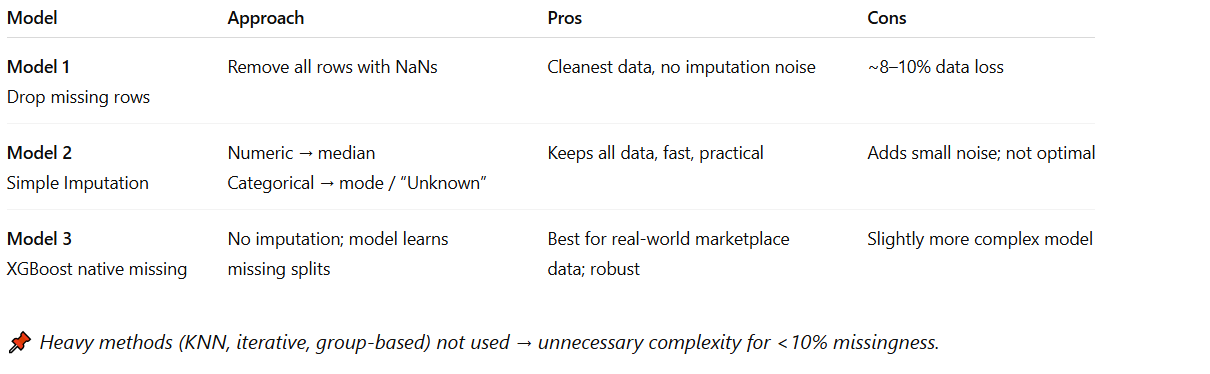!

#### Numerical Columns Analysis
#### Step-9. Numerical Summary

In [22]:
# Initial Numerical Analysis
numeric_columns = [ 'total_items','subtotal','num_distinct_items', 'min_item_price', 'max_item_price', 'total_onshift_dashers', 'total_busy_dashers',
                   	'total_outstanding_orders', 'estimated_order_place_duration', 'estimated_store_to_consumer_driving_duration', 'delivery_duration_seconds'
                   ]
df[numeric_columns].describe()
     

,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,estimated_store_to_consumer_driving_duration,delivery_duration_seconds
count,196059.000000,196059.000000,196059.000000,196059.000000,196059.000000,179918.000000,179918.000000,179918.000000,196059.000000,195535.000000,1.960520e+05
mean,3.205525,2690.329304,2.678893,683.204081,1159.055264,44.828427,41.755778,58.078564,308.509255,545.311949,2.909074e+03
std,2.667563,1824.537149,1.630607,519.468118,557.509297,34.536089,32.149271,52.673657,90.124942,219.365256,1.929640e+04
min,1.000000,95.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.010000e+02
25%,2.000000,1411.000000,2.000000,299.000000,800.000000,17.000000,15.000000,17.000000,251.000000,382.000000,2.105000e+03
50%,3.000000,2210.000000,2.000000,595.000000,1095.000000,37.000000,34.000000,41.000000,251.000000,544.000000,2.661000e+03
75%,4.000000,3400.000000,3.000000,942.000000,1395.000000,65.000000,62.000000,85.000000,446.000000,702.000000,3.382000e+03
max,411.000000,27100.000000,20.000000,14700.000000,14700.000000,171.000000,154.000000,285.000000,2715.000000,2088.000000,8.516859e+06



Insights:

Extreme Outliers: All mentioned numeric columns

Skewed columns: All mentioned numeric columns except estimated_store_to_consumer_driving_duration

Balanced Column: estimated_store_to_consumer_driving_duration shows near-normal distribution.


##### Step-10. Distribution of Numeric columns - Visualization Plot

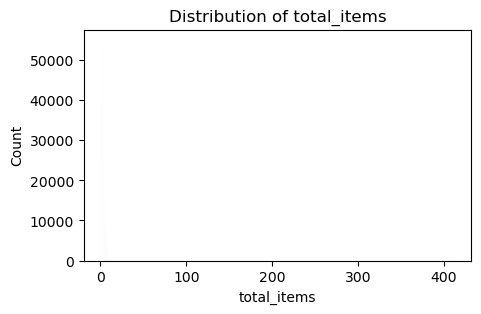

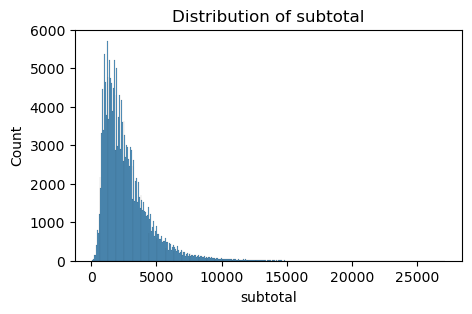

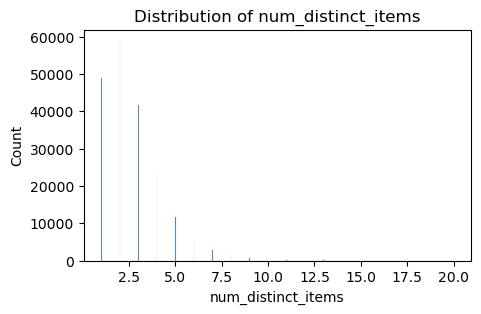

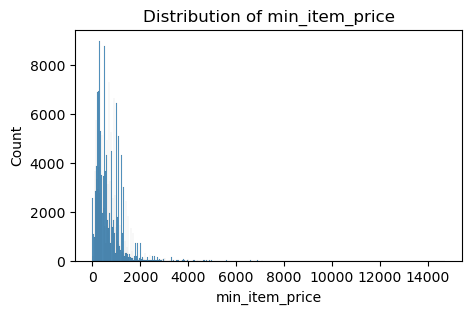

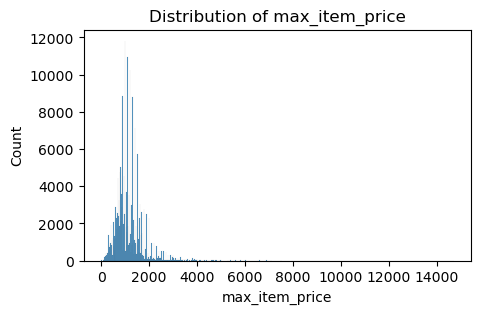

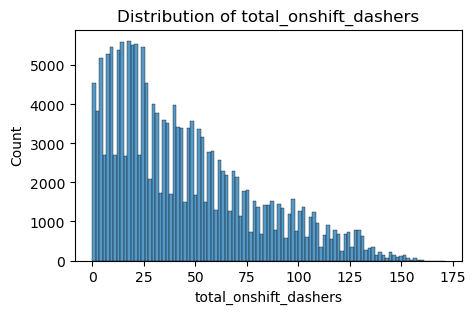

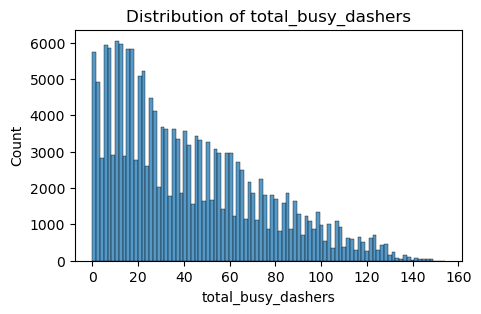

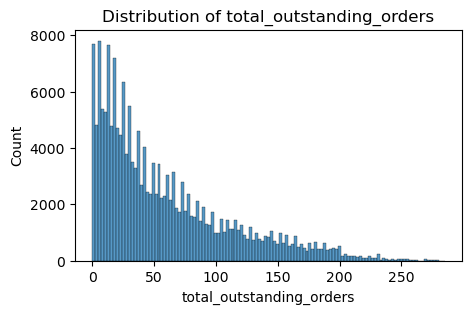

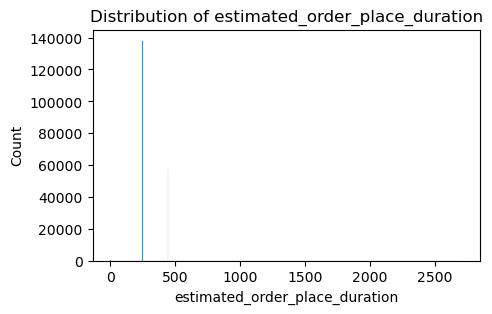

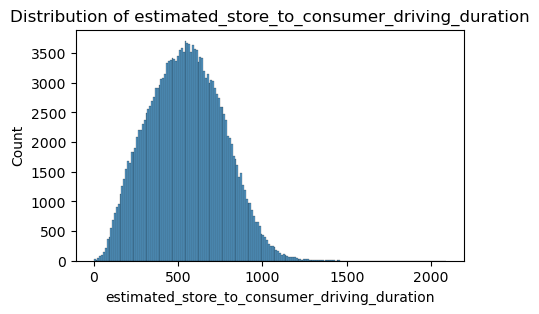

In [23]:
for col in numeric_columns:
    if col != 'delivery_duration_seconds':
        plt.figure(figsize=(5,3))
        sns.histplot(df[col])
        plt.title(f"Distribution of {col}")
        plt.show()



### 📊 1️⃣ Subtotal Distribution

### 🔎 Observations:

* Highly **right-skewed distribution**
* Most orders are between **₹0 – ₹5000**
* Very few orders go up to **₹25,000+**
* Presence of **extreme outliers**

### 📌 Insights:

* Customers mostly place **low-to-medium value orders**
* High-value orders are rare but may strongly influence revenue
* Mean > Median (because of skewness)

### 🤖 ML Impact:

* Consider **log transformation**
* Use **RobustScaler instead of StandardScaler**
* Check outliers before training

---

# 📦 2️⃣ num_distinct_items

### 🔎 Observations:

* Majority orders have **2–4 distinct items**
* Very few orders have more than 6–7 items
* Looks like a **discrete count variable**

### 📌 Insights:

* Customers usually order limited variety
* Bulk orders are rare

### 🤖 ML Impact:

* Treat as **integer feature**
* Could correlate strongly with subtotal

---

# 💰 3️⃣ min_item_price

### 🔎 Observations:

* Strong right skew
* Most minimum item prices are below ₹2000
* Few extreme values up to ₹14000

### 📌 Insights:

* Most stores sell affordable items
* Some stores have premium products

### 🤖 ML Impact:

* Outlier handling needed
* Try log scaling

---

#### 💎 4️⃣ max_item_price

### 🔎 Observations:

* Also right-skewed
* Most max prices are concentrated in lower range
* Few very expensive items

### 📌 Insights:

* Product catalog is dominated by low-mid price items
* Some high-ticket products exist

### 🤖 ML Impact:

* Possible multicollinearity with subtotal
* Feature importance check required

---

# 🚴 5️⃣ total_onshift_dashers

### 🔎 Observations:

* Right skewed
* Most values between 0–60
* Rare cases above 150

### 📌 Insights:

* Workforce availability varies
* High supply scenarios are rare

### 🤖 ML Impact:

* Important operational feature
* Check correlation with delivery time

---

### 🚴‍♂️ 6️⃣ total_busy_dashers

### 🔎 Observations:

* Similar pattern to onshift_dashers
* Majority under 60
* Long right tail

### 📌 Insights:

* Demand pressure fluctuates
* Likely strong predictor of delay

### 🤖 ML Impact:

* Create feature:
  `busy_ratio = total_busy_dashers / total_onshift_dashers`

This will be powerful 🚀

---

#### 📦 7️⃣ total_outstanding_orders

### 🔎 Observations:

* Heavy right skew
* Most orders < 100
* Some extreme spikes up to 250+

### 📌 Insights:

* Platform congestion varies
* High outstanding → longer delivery time

### 🤖 ML Impact:

* Strong candidate for predicting:

  * delivery_duration_seconds
  * delay classification

---

#### ⏱ 8️⃣ estimated_order_place_duration

### 🔎 Observations:

* Huge spike at specific value (~300–400 seconds)
* Looks like **default system estimate**
* Very little variation

### 📌 Insights:

* System may use standard fixed time
* Not very informative feature

### 🤖 ML Impact:

* Low variance → low predictive power
* Consider dropping if confirmed

---

# 🚨 Global Dataset Insights

### 1️⃣ Almost all numerical variables are **right skewed**

→ Log transform recommended

### 2️⃣ Outliers present in:

* subtotal
* min_item_price
* max_item_price
* outstanding orders

### 3️⃣ Operational variables (dashers + outstanding orders)

Likely strongest predictors for:

* delivery duration
* service delay

---

#### 🎯 If Your Target is `delivery_duration_seconds`

Most important candidate features:

1. total_busy_dashers
2. total_outstanding_orders
3. estimated_store_to_consumer_driving_duration
4. busy_ratio (engineered feature)
5. subtotal

---

#### 🧠 Interview-Ready Conclusion

> The dataset is highly right-skewed with operational congestion features showing long-tail behavior. Log transformation and outlier treatment will improve model stability. Operational variables such as busy dashers and outstanding orders are likely strong predictors of delivery duration.

---



#### Step-11. Distribution of Outliers in Numeric columns - Visualization Plot


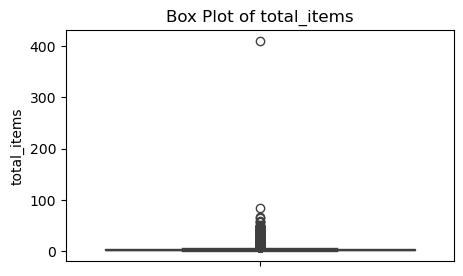

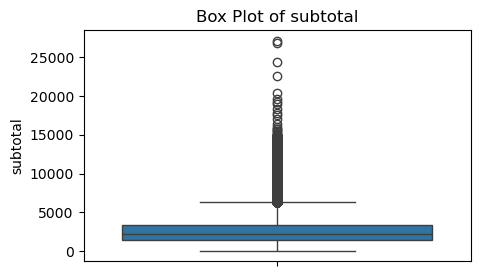

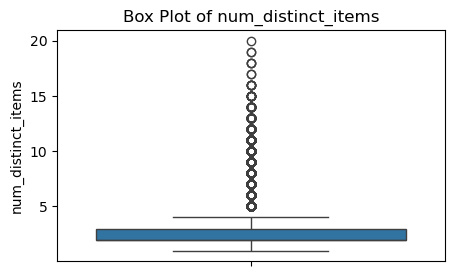

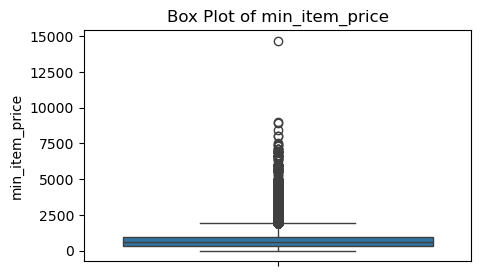

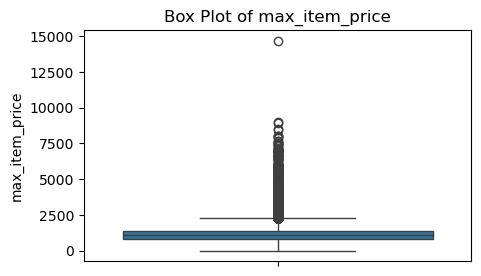

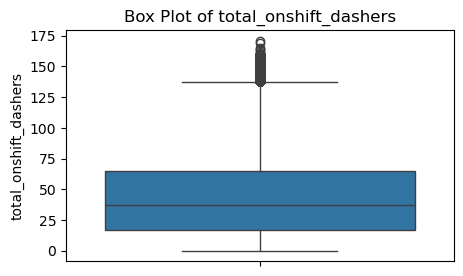

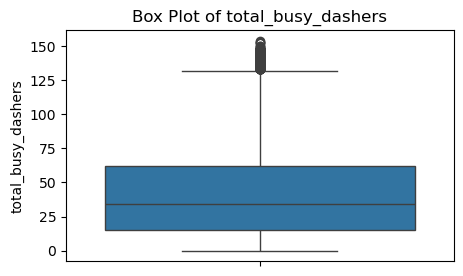

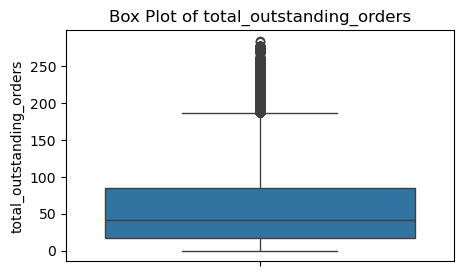

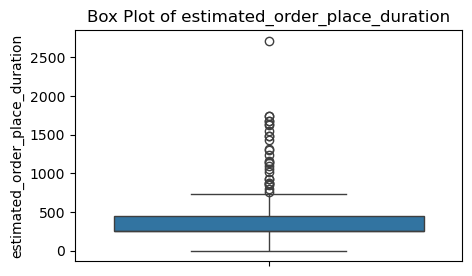

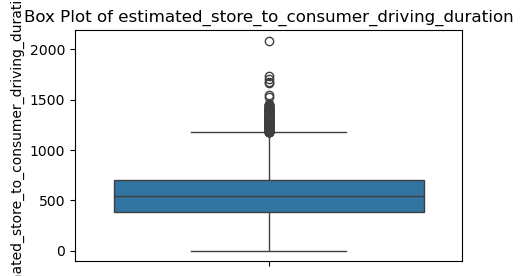

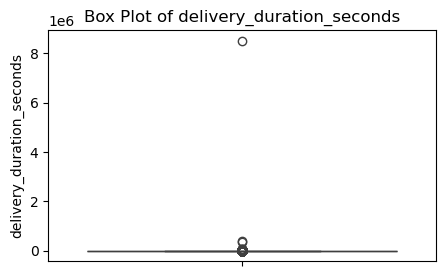

In [24]:
for col in numeric_columns:
    plt.figure(figsize=(5,3))
    sns.boxplot(df[col])
    plt.title(f"Box Plot of {col}")
    plt.show()


#### Insights: All numeric columns have outliers.

In [25]:
for col in num_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q1-Q3
    lower_bound = Q1 -1.5*IQR
    upper_bound = Q3 + 1.5*IQR
    outliers = df[(df[col]<lower_bound)|(df[col]>upper_bound)][col]
    print(f'{col}:')
    print(f'  Total outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)')
    print(f'  Range: [{lower_bound:.2f}, {upper_bound:.2f}]')
    print(f'  Min outlier: {outliers.min():.2f}, Max outlier: {outliers.max():.2f}')
    print('-' * 50)



market_id:
  Total outliers: 195081 (99.50%)
  Range: [5.00, 1.00]
  Min outlier: 1.00, Max outlier: 6.00
--------------------------------------------------
store_id:
  Total outliers: 196059 (100.00%)
  Range: [7105.50, -120.50]
  Min outlier: 1.00, Max outlier: 6987.00
--------------------------------------------------
order_protocol:
  Total outliers: 195070 (99.50%)
  Range: [5.50, -0.50]
  Min outlier: 1.00, Max outlier: 7.00
--------------------------------------------------
total_items:
  Total outliers: 196059 (100.00%)
  Range: [5.00, 1.00]
  Min outlier: 1.00, Max outlier: 411.00
--------------------------------------------------
subtotal:
  Total outliers: 196059 (100.00%)
  Range: [4394.50, 416.50]
  Min outlier: 95.00, Max outlier: 27100.00
--------------------------------------------------
num_distinct_items:
  Total outliers: 196059 (100.00%)
  Range: [3.50, 1.50]
  Min outlier: 1.00, Max outlier: 20.00
--------------------------------------------------
min_item_price:
 

Outlier Handling Summary

Keep meaningful long-tailed outliers (marketplace spikes).

Remove only extreme/unrealistic values (e.g., 98-day delivery).

Use robust models (RF, XGBoost) and MAE metric.

Extreme/Unrealistic Outliers

total_items has an extreme outlier - 411, need to check this data point more specifically.

same with min_item_price and max_item_price which has extreme outlier as 14700

Target variable(delivery_duration_seconds) has an extreme outlier(8516859.00-98days) need to analyse it carefully

#### 1a. Analysis of extreme outliers in target variable(delivery_duration_seconds)

An **outlier deep dive** means you don't remove every statistical outlier. Instead, you **investigate only the extreme values** to determine whether they are **real observations** or **data quality issues**.

You can explain it like this:

---

## b. Outlier Deep Dive in Numeric Features

Instead of treating every statistical outlier as an error, the analysis focused only on **extreme values** that were highly unlikely to occur in real-world food delivery operations.

### Why focus only on extreme cases?

Food delivery data naturally contains variability. Some orders genuinely experience:

* Heavy traffic
* Restaurant preparation delays
* Dasher shortages
* Weather disruptions
* Customer unavailability

These situations create long delivery times that are **valid operational events**, not errors. Removing all statistical outliers (e.g., values above the 99th percentile) would discard important information that the model needs to learn.

### Approach Used

* Investigated only the most extreme observations in each numeric feature.
* Compared these values with realistic business limits.
* Removed only observations that were operationally impossible or clearly caused by data errors.
* Retained unusually large but plausible values because they represent real marketplace behavior.

### Example: Delivery Duration

The maximum delivery durations included values such as:

* **98 days**
* **4 days**
* **3.8 days**

These are impossible for a food delivery service and indicate timestamp or recording errors.

Therefore:

* ❌ Removed only delivery durations greater than **12 hours (43,200 seconds)**.
* Only **7 rows** were removed.
* ✔ All delivery durations up to **12 hours** were retained, even if they were statistical outliers, because they may represent genuine operational delays.

### Why not remove all outliers?

Using a purely statistical rule such as removing values above the **99th percentile (≈1.77 hours)** would eliminate many legitimate delayed deliveries caused by real operational conditions. Such delays are valuable for training an ETA prediction model because they help the model understand worst-case delivery scenarios.

### Conclusion

The outlier treatment was **business-driven rather than purely statistical**. Only impossible extreme values were removed to correct data quality issues, while realistic but rare observations were preserved to maintain the integrity and predictive power of the dataset.


In [26]:
#df[df['delivery_duration_seconds']>= 43200][['delivery_duration_seconds']].sort_values(
#   by='delivery_duration_seconds',ascending=False)
df[df["delivery_duration_seconds"]>=43200][["delivery_duration_seconds"]].sort_values(
by = "delivery_duration_seconds",ascending=False
)

,delivery_duration_seconds
2690,8516859.0
185550,373879.0
27189,332482.0
83055,57032.0
190860,54447.0
86952,48178.0
76743,45685.0


Delivery duration is naturally right-skewed and some long delays are real operational events → keep them.
Very large values (e.g., 98 days, 4 days, 3.8 days) are timestamp errors, not real delays.
Approach used:

❌ Remove only impossible values: delivery_duration_seconds > 12 hours (43,200 sec) → Only 7 rows removed.
✔ Keep all realistic long delays (≤ 12 hours) because they capture real marketplace conditions.
Reasoning:

Removing > 99th percentile(1.77hr) would delete valid delays (traffic, dasher shortage, store backlog).

Removing >12hrs cleans only corrupted data without losing meaningful signal.

#### b. outlier deep dive in numeric features- lets concentrate only on extreme cases

In [27]:
# For total_items there is an extreme outlier where total_items value is 411
df[df['total_items']==411]

    

,market_id,created_at,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,estimated_store_to_consumer_driving_duration,delivery_duration_seconds
47231,2.0,2015-02-06 00:42:39,777,fast,4.0,411,3115,5,0,299,35.0,35.0,39.0,251,573.0,3055.0


In [28]:
# For min_item_price and max_item_price extreme outlier analysis
df[df['min_item_price'] == 14700]

,market_id,created_at,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,estimated_store_to_consumer_driving_duration,delivery_duration_seconds
139718,3.0,2015-02-04 01:35:22,2580,breakfast,5.0,1,14700,1,14700,14700,23.0,21.0,22.0,251,934.0,5235.0


In [29]:
df[df['max_item_price']==14700]
     

,market_id,created_at,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,estimated_store_to_consumer_driving_duration,delivery_duration_seconds
139718,3.0,2015-02-04 01:35:22,2580,breakfast,5.0,1,14700,1,14700,14700,23.0,21.0,22.0,251,934.0,5235.0


In [30]:
# Remove extreme outliers in these columns
df = df[df['total_items'] != 411]
df = df[df['min_item_price']!= 14700]
df = df[df['max_item_price'] != 14700]
#df = df[df['max_item_price'] != 14700]
# Remove impossible delivery durations > 12 hours (43,200 sec)
#df = df[df['delivery_duration_seconds'] <= 43200]
df = df[df['delivery_duration_seconds'] <= 43200]


In [31]:
print("Retained data", (len(df)/original_df_len)*100)

Retained data 99.2984784326438


## Categorical Columns Analysis
### Step-14. Distribution of Categories

In [32]:
categorical_columns = ['market_id', 'store_id', 'store_primary_category', 'order_protocol']
n = len(df)
for col in categorical_columns:
    res = pd.DataFrame(df[col].value_counts())
    res["per"] = res["count"]*100/n
    print(res)
    print('-'*50)

           count        per
market_id                  
2.0        54698  27.901022
4.0        47309  24.131951
1.0        37738  19.249858
3.0        23104  11.785170
5.0        17870   9.115347
6.0        14346   7.317782
--------------------------------------------------
          count       per
store_id                 
6865        932  0.475406
1311        854  0.435619
314         809  0.412665
1686        756  0.385630
3937        720  0.367266
...         ...       ...
4021          1  0.000510
5398          1  0.000510
3201          1  0.000510
5926          1  0.000510
4141          1  0.000510

[6738 rows x 2 columns]
--------------------------------------------------
                        count       per
store_primary_category                 
american                19255  9.821825
pizza                   17188  8.767464
mexican                 16979  8.660855
burger                  10904  5.562045
sandwich                 9978  5.089700
...                       ...  

Perfect 👌 I’ll explain this in **very simple language**, step by step.

---

# 🔹 1️⃣ “Extract temporal patterns from `created_at` column” — What does this mean?

If you have a column like:

```text
2024-01-15 18:32:10
```

This is a **date + time**.

Instead of using it directly, we break it into useful parts like:

* 📅 Day of week (Monday, Tuesday…)
* 📆 Month
* ⏰ Hour of day
* 🗓 Weekend or not
* 🌙 Peak time or non-peak time

---

### Why?

Because customer behavior changes based on time.

Example:

* More orders on **Friday night**
* More rush during **8–10 PM**
* Fewer dashers at **3 AM**

So instead of giving full datetime to model, we give:

```python
df["hour"] = df["created_at"].dt.hour
df["day_of_week"] = df["created_at"].dt.dayofweek
df["is_weekend"] = df["day_of_week"].isin([5,6])
```

This is called **temporal feature engineering**.

---

# 🔹 2️⃣ Encoding Categorical Variables (Easy Explanation)

Suppose you have a column:

```text
store_type = ["A", "B", "C"]
```

Models cannot understand text.
They understand only numbers.

So we convert categories into numbers.

---

# 🔥 Case 1: Tree-Based Models (Random Forest, XGBoost)

Tree models:

* Random Forest
* XGBoost
* Decision Tree

👉 They handle categories very well even if encoded simply.

So you can do:

```python
Label Encoding
A → 0
B → 1
C → 2
```

Even though numbers look ordered, trees don't care much.

So **simple encoding works fine**.

---

# 🔥 Case 2: Linear Models (Linear Regression, Logistic Regression)

Linear models assume:

```
Higher number = bigger impact
```

If you do:

```text
A = 0
B = 1
C = 2
```

Model thinks:
C > B > A (which may not be true!)

That creates wrong relationships.

---

### So what do we do?

We use:

### ✅ One-Hot Encoding

```text
A → [1,0,0]
B → [0,1,0]
C → [0,0,1]
```

Now model treats all categories equally.

---

### ✅ Target Encoding (Advanced)

Replace category with its average target value.

Example:

If predicting delivery time:

```
Store A → Avg delivery = 20 mins
Store B → Avg delivery = 35 mins
```

Then encode:

```
A → 20
B → 35
```

Good for large datasets.

---

# 🎯 So in Simple Words:

If data is **non-linear** → use Tree models
→ Label encoding is enough

If data is **linear** → use Linear models
→ Use One-hot or Target encoding

---

# 💡 Very Simple Analogy

Tree model = Smart decision maker
Linear model = Formula-based calculator

Calculator needs proper format (one-hot)
Smart decision maker can adjust easily (label encoding)

---



#### Step 15 Correlation Analysis

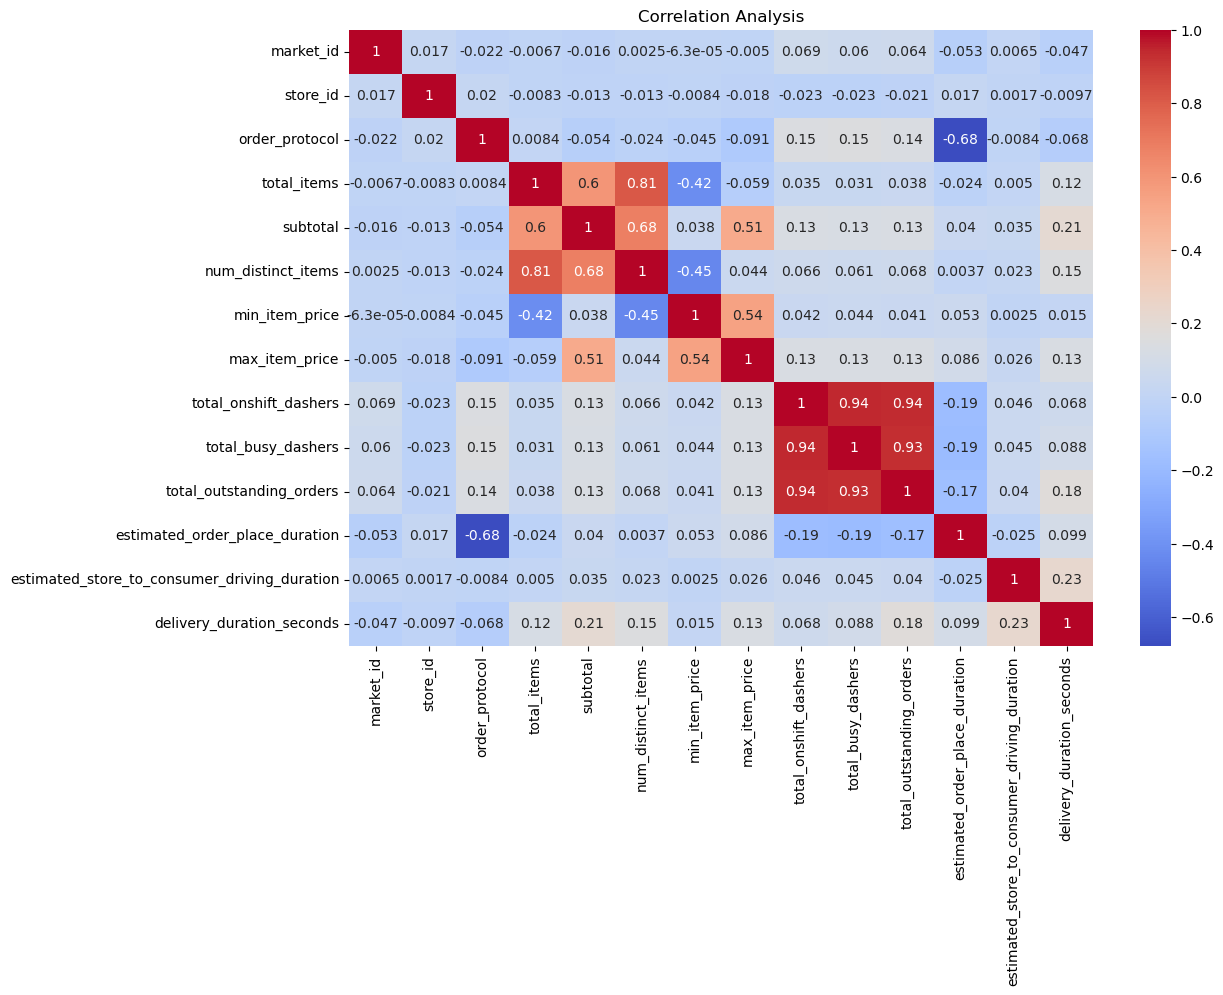

In [33]:
plt.figure(figsize=(12,8))
sns.heatmap(df[num_columns].corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Analysis")
plt.show()

Insights:

Order size features (total_items, subtotal, num_distinct_items) are strongly correlated with each other. Tree models handle this naturally

Marketplace features (total_onshift_dashers, total_busy_dashers, total_outstanding_orders) are very highly correlated with each other → strong multicollinearity. Tree models handle this naturally.

Strongest correlations with delivery duration are:

estimated_store_to_consumer_driving_duration (0.23)

subtotal (0.21)

Overall low correlations (<0.30) indicate the problem is non-linear, supporting the use of Tree Based Models over linear models.

Very good question 👌 This is an important ML concept.
I’ll explain it in **very simple language**.

---

# 🔹 Statement:

> Overall low correlations (< 0.30) indicate the problem is non-linear, supporting the use of Tree Based Models over linear models.

---

# 🔎 Step 1: What is Correlation?

Correlation measures:

> How strongly two variables move in a straight-line relationship.

Range:

* +1 → Strong positive linear relationship
* 0 → No linear relationship
* -1 → Strong negative linear relationship

---

### Example of Strong Linear Relationship:

If:

```
driving_distance ↑ → delivery_time ↑
```

And they increase almost in a straight line → correlation will be high (like 0.8).

---

# 🔎 Step 2: What Does Low Correlation (< 0.30) Mean?

It means:

> There is no strong straight-line relationship between feature and target.

Example:

Suppose:

```
busy_dashers vs delivery_time
```

Maybe:

* When dashers are 0–20 → time is moderate
* When dashers are 20–40 → time decreases
* When dashers are 40–80 → time increases again

This is not a straight line.

So correlation becomes low.

---

# 🔥 Important:

Low correlation ≠ no relationship
It means:

> No **linear** relationship.

There may still be a **non-linear relationship**.

---

# 🔎 Step 3: Why Linear Models Struggle

Linear Regression assumes:

```
target = a + b1*x1 + b2*x2
```

This is a straight-line formula.

If relationship is curved, complex, or interaction-based:

👉 Linear model cannot capture it well.

---

# 🔎 Step 4: Why Tree Models Work Better

Tree-based models (Random Forest, XGBoost):

They don’t assume straight-line relationships.

They split like:

```
If busy_dashers > 50 → increase time
If subtotal > 2000 AND weekend → increase time
```

They capture:

* Non-linearity
* Interactions
* Threshold effects

---

# 🎯 Simple Example

Imagine this pattern:

```
Low traffic → normal time
Medium traffic → fastest
High traffic → slowest
```

Graph looks like U-shape.

Correlation ≈ 0
But relationship clearly exists!

Linear model fails.
Tree model captures it.

---

# 🧠 So What That Statement Means:

Because most features have correlation less than 0.30:

👉 There is no strong straight-line pattern.
👉 Relationship is likely complex and non-linear.
👉 Tree models are better suited.

---

# 🚀 In Interview Language

You can say:

> The weak linear correlations suggest the target does not depend on features in a strictly linear manner. Therefore, tree-based models, which capture non-linear relationships and feature interactions, are more appropriate than linear regression.



In [34]:
corr_matrix = df.corr(numeric_only=True)
corr_matrix

,market_id,store_id,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,estimated_store_to_consumer_driving_duration,delivery_duration_seconds
market_id,1.000000,0.017337,-0.022052,-0.006730,-0.016224,0.002531,-0.000063,-0.005035,0.069473,0.060224,0.063507,-0.053062,0.006484,-0.047035
store_id,0.017337,1.000000,0.019634,-0.008273,-0.013075,-0.012740,-0.008434,-0.018001,-0.023210,-0.023266,-0.020502,0.017299,0.001652,-0.009693
order_protocol,-0.022052,0.019634,1.000000,0.008440,-0.054245,-0.023542,-0.045401,-0.091232,0.145350,0.149901,0.135165,-0.678102,-0.008400,-0.067715
total_items,-0.006730,-0.008273,0.008440,1.000000,0.595413,0.812592,-0.417502,-0.059454,0.034589,0.031229,0.037568,-0.024427,0.004969,0.121044
subtotal,-0.016224,-0.013075,-0.054245,0.595413,1.000000,0.682222,0.037522,0.507829,0.131255,0.126032,0.130542,0.039618,0.034741,0.208852
num_distinct_items,0.002531,-0.012740,-0.023542,0.812592,0.682222,1.000000,-0.448272,0.043569,0.066431,0.061177,0.068319,0.003691,0.022829,0.150849
min_item_price,-0.000063,-0.008434,-0.045401,-0.417502,0.037522,-0.448272,1.000000,0.541322,0.042052,0.043519,0.040598,0.053159,0.002539,0.014986
max_item_price,-0.005035,-0.018001,-0.091232,-0.059454,0.507829,0.043569,0.541322,1.000000,0.133476,0.131368,0.131071,0.085569,0.026018,0.128796
total_onshift_dashers,0.069473,-0.023210,0.145350,0.034589,0.131255,0.066431,0.042052,0.133476,1.000000,0.943816,0.936112,-0.185636,0.046022,0.068283
total_busy_dashers,0.060224,-0.023266,0.149901,0.031229,0.126032,0.061177,0.043519,0.131368,0.943816,1.000000,0.932963,-0.191710,0.044568,0.087882


This is a **Pearson correlation matrix**, which measures the **linear relationship** between pairs of numerical variables.

* Correlation ranges from **-1 to +1**.
* **+1** = perfect positive relationship.
* **0** = no linear relationship.
* **-1** = perfect negative relationship.

For your ETA prediction project, here are the key insights.

---

## 1. Order size features are strongly correlated

| Features                             | Correlation |
| ------------------------------------ | ----------: |
| `total_items` ↔ `num_distinct_items` |   **0.813** |
| `subtotal` ↔ `num_distinct_items`    |   **0.682** |
| `total_items` ↔ `subtotal`           |   **0.595** |

### What does this mean?

These variables all measure different aspects of the **size of an order**.

For example:

* More items generally mean a higher subtotal.
* More items often mean more distinct menu items.

Example:

| Order  | Total Items | Distinct Items | Subtotal |
| ------ | ----------: | -------------: | -------: |
| Small  |           3 |              2 |     ₹350 |
| Medium |           8 |              5 |     ₹900 |
| Large  |          25 |             10 |    ₹3200 |

As order size increases, these features tend to increase together, resulting in high positive correlations.

---

## 2. Marketplace features are highly correlated

| Features                                             | Correlation |
| ---------------------------------------------------- | ----------: |
| `total_onshift_dashers` ↔ `total_busy_dashers`       |   **0.944** |
| `total_onshift_dashers` ↔ `total_outstanding_orders` |   **0.936** |
| `total_busy_dashers` ↔ `total_outstanding_orders`    |   **0.933** |

### What does this mean?

These variables describe the **state of the marketplace** at the time of the order.

For example:

| Busy Hour | Dashers | Busy Dashers | Outstanding Orders |
| --------- | ------- | ------------ | ------------------ |
| Noon      | High    | High         | High               |
| Midnight  | Low     | Low          | Low                |

They naturally increase and decrease together.

---

## 3. Strongest relationships with delivery time

Look at the last column (`delivery_duration_seconds`).

| Feature                                        | Correlation |
| ---------------------------------------------- | ----------: |
| `estimated_store_to_consumer_driving_duration` |   **0.227** |
| `subtotal`                                     |   **0.209** |
| `total_outstanding_orders`                     |   **0.176** |
| `num_distinct_items`                           |   **0.151** |
| `max_item_price`                               |   **0.129** |
| `total_items`                                  |   **0.121** |

### Interpretation

#### `estimated_store_to_consumer_driving_duration` (0.227)

This is the strongest predictor among the numerical features.

It makes intuitive sense:

> Longer estimated driving time generally leads to longer delivery time.

---

#### `subtotal` (0.209)

Higher-value orders often:

* contain more food,
* require longer preparation,
* take longer to pack.

So delivery duration tends to increase slightly.

---

#### `total_outstanding_orders` (0.176)

When many orders are waiting:

* restaurants become busier,
* dashers are occupied,
* deliveries may be delayed.

---

## 4. Why are all correlations below 0.30?

This is one of the most important findings.

The highest correlation is only **0.227**.

That means **no single feature has a strong linear relationship** with delivery duration.

Delivery time depends on many factors interacting together:

* restaurant workload,
* traffic,
* order size,
* driver availability,
* driving distance,
* protocol,
* time of day,
* and other factors.

For example:

* A **large order** may still arrive quickly if the restaurant is empty and a dasher is nearby.
* A **small order** may be delayed during rush hour because no dashers are available.

These interactions are **non-linear**, so a simple linear model cannot capture them well.

---

## 5. Why are tree-based models preferred?

Linear models assume a relationship like:

[
\text{Delivery Time} = a + b_1x_1 + b_2x_2 + \cdots
]

This assumes each feature contributes independently and linearly.

Tree-based models (such as Random Forest, XGBoost, and LightGBM) can instead learn rules like:

* **If** driving distance is high **and** restaurant is busy → longer ETA.
* **If** order is small **but** no dashers are available → longer ETA.
* **If** subtotal is high **and** outstanding orders are high → longer preparation time.

They automatically capture these interactions without requiring strong linear correlations.

---

## 6. What about multicollinearity?

High correlations (e.g., **0.94**) between the marketplace features indicate **multicollinearity**, meaning they contain overlapping information.

* **Linear regression** can suffer from unstable coefficient estimates when predictors are highly correlated, so feature selection or regularization is often needed.
* **Tree-based models** are much less sensitive to multicollinearity. They select splits based on predictive value and can naturally handle correlated features, so all these variables can usually be retained.

### Summary

* **Order size features** (`total_items`, `subtotal`, `num_distinct_items`) are strongly correlated because they all represent the size of an order.
* **Marketplace features** (`total_onshift_dashers`, `total_busy_dashers`, `total_outstanding_orders`) are highly correlated because they describe the same marketplace conditions.
* The strongest linear relationship with delivery duration is **`estimated_store_to_consumer_driving_duration` (0.227)**, followed by **`subtotal` (0.209)**, but these correlations are still relatively weak.
* Since all correlations with the target are below **0.30**, delivery duration is influenced by complex, non-linear interactions among multiple variables. This supports using **tree-based machine learning models** (e.g., Random Forest, XGBoost, LightGBM) rather than relying solely on linear regression.


In [35]:
target = "delivery_duration_seconds"

corr_with_target = df.corr(numeric_only=True)[target].drop(target)
abs_corr = corr_with_target.abs()

print(abs_corr)

market_id                                       0.047035
store_id                                        0.009693
order_protocol                                  0.067715
total_items                                     0.121044
subtotal                                        0.208852
num_distinct_items                              0.150849
min_item_price                                  0.014986
max_item_price                                  0.128796
total_onshift_dashers                           0.068283
total_busy_dashers                              0.087882
total_outstanding_orders                        0.176425
estimated_order_place_duration                  0.099141
estimated_store_to_consumer_driving_duration    0.227423
Name: delivery_duration_seconds, dtype: float64


(abs_corr < 0.30).sum()
#####  computed Pearson correlation between numerical features and the target variable. Since most absolute correlations were below 0.30, it indicates weak linear relationships. Therefore, I explored non-linear models like Random Forest and XGBoost.

That means:

Most features have weak linear relationship
So linear regression may not perform strongly
Tree models may be better

#### Step16. Feature-Target Relationships

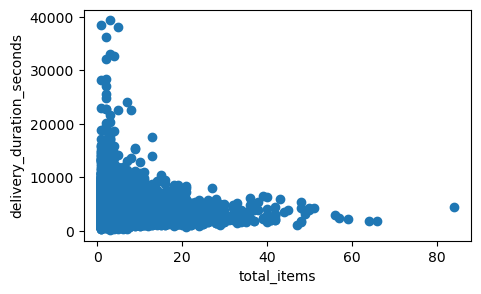

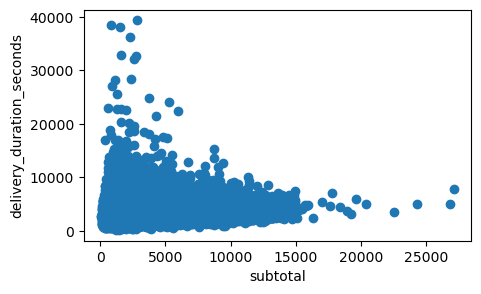

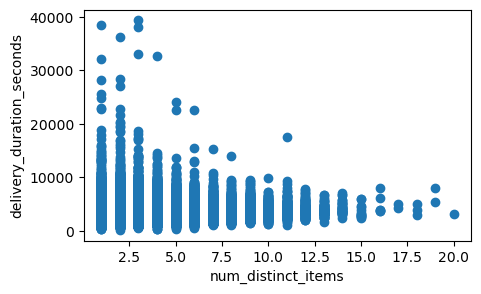

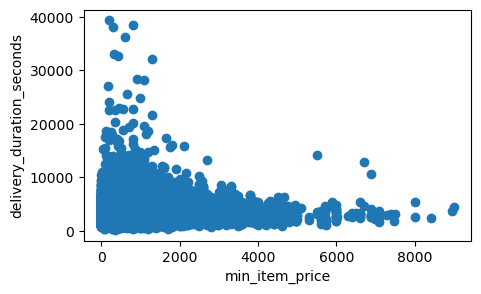

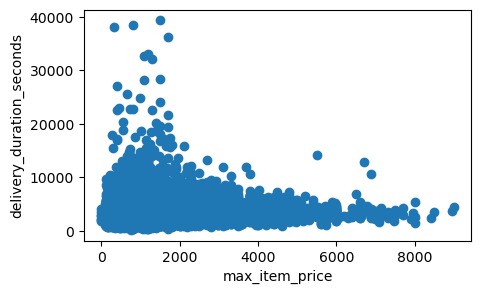

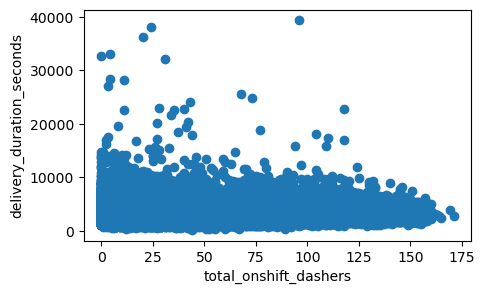

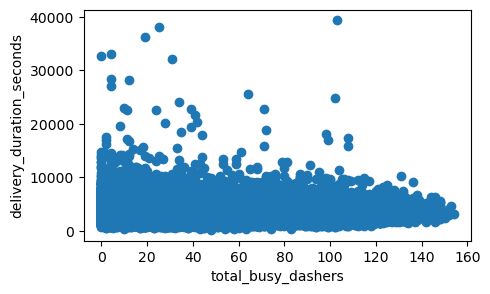

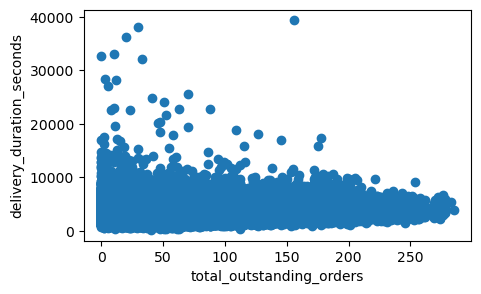

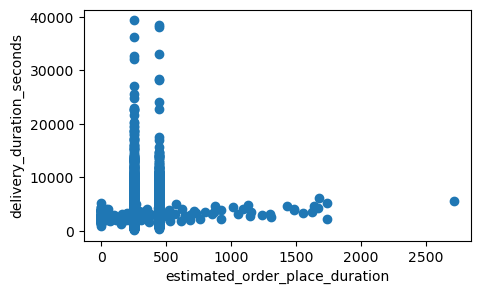

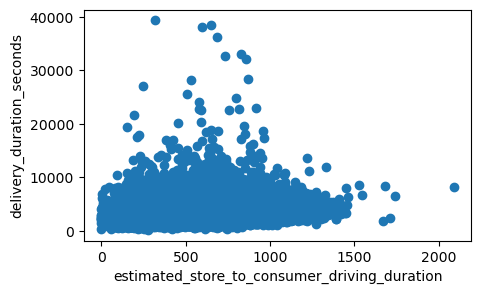

In [36]:
numeric_features = [ 'total_items','subtotal','num_distinct_items', 'min_item_price', 'max_item_price', 'total_onshift_dashers', 'total_busy_dashers',
                   	'total_outstanding_orders', 'estimated_order_place_duration', 'estimated_store_to_consumer_driving_duration'
                   ]
for col in numeric_features:
    plt.figure(figsize=(5,3))
    plt.scatter(df[col],df['delivery_duration_seconds'])
    plt.xlabel(col)
    plt.ylabel('delivery_duration_seconds')
    plt.show()

📌 Feature–Target Relationship (Scatter Plot Insights)

Scatterplots of all numeric features vs delivery_duration_seconds show no linear pattern.

Outliers heavily distort linear models but tree models (DecisionTree, RandomForest, XGBoost) handle them well.

Overall, the target variable shows complex, multi-factor behavior, confirming that linear regression would have high bias.

✔ Model Recommendation

Start directly with tree-based models because they:

handle non-linearity

capture interactions

are robust to skewness & outliers

require no scaling or log transforms

| **Step**                            | **What Was Checked**                                                               | **Key Findings**                                                                                                                                                                                   | **Action Taken**                                                                                   |
| ----------------------------------- | ---------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------- |
| **1. Duplicate Check**              | Duplicate rows                                                                     | No duplicate records found.                                                                                                                                                                        | No action required.                                                                                |
| **2. Datetime Handling**            | `created_at`, `actual_delivery_time`                                               | Both columns were successfully parsed as datetime objects.                                                                                                                                         | Converted to datetime and used to create the target variable.                                      |
| **3. Target Creation**              | `delivery_duration_seconds`                                                        | No negative delivery durations were observed.                                                                                                                                                      | Created the target variable and removed `actual_delivery_time` to prevent data leakage.            |
| **4. Basic Validity Checks**        | Logical constraints (`min_item_price ≤ max_item_price`, prices ≤ `subtotal`, etc.) | Approximately **0.4%** of records violated business rules.                                                                                                                                         | Dropped invalid records.                                                                           |
| **5. Negative Values**              | All numeric features                                                               | Only **0.04%** of records contained negative values where not expected.                                                                                                                            | Removed invalid rows.                                                                              |
| **6. Busy > Onshift Dashers**       | `total_busy_dashers` vs. `total_onshift_dashers`                                   | Many records had busy dashers exceeding on-shift dashers, likely due to data pipeline timing lag.                                                                                                  | Retained since it reflects real marketplace conditions.                                            |
| **7. Extreme Outliers**             | `total_items`, `min_item_price`, `max_item_price`, `delivery_duration_seconds`     | Extreme values such as `total_items = 411` and high item prices were found to be business-plausible, whereas delivery durations exceeding **12 hours** were identified as timestamp/system errors. | Retained plausible outliers; removed only unrealistic values (e.g., delivery duration > 12 hours). |
| **8. Missing Values**               | `market_id`, `store_primary_category`, `order_protocol`, dasher-related features   | Less than **10%** missing values across these features.                                                                                                                                            | Missing values will be handled separately in different modeling strategies (Models 1–3).           |
| **9. Skewness & Distributions**     | Distribution of numeric features                                                   | Most numeric variables were right-skewed; `estimated_store_to_consumer_driving_duration` was approximately normally distributed.                                                                   | No scaling or log transformation applied, as tree-based models are robust to skewed distributions. |
| **10. Feature Correlation**         | Pearson correlation matrix                                                         | Strong multicollinearity among order-size and marketplace features; weak linear correlation (<0.30) with the target.                                                                               | Retained all features since tree-based models are robust to multicollinearity.                     |
| **11. Feature–Target Scatterplots** | Relationship between features and target                                           | Scatterplots showed predominantly non-linear relationships with delivery duration.                                                                                                                 | Supports the use of tree-based machine learning models (Random Forest, XGBoost, LightGBM).         |


#### 5. Handling Missing Values & Model Selection
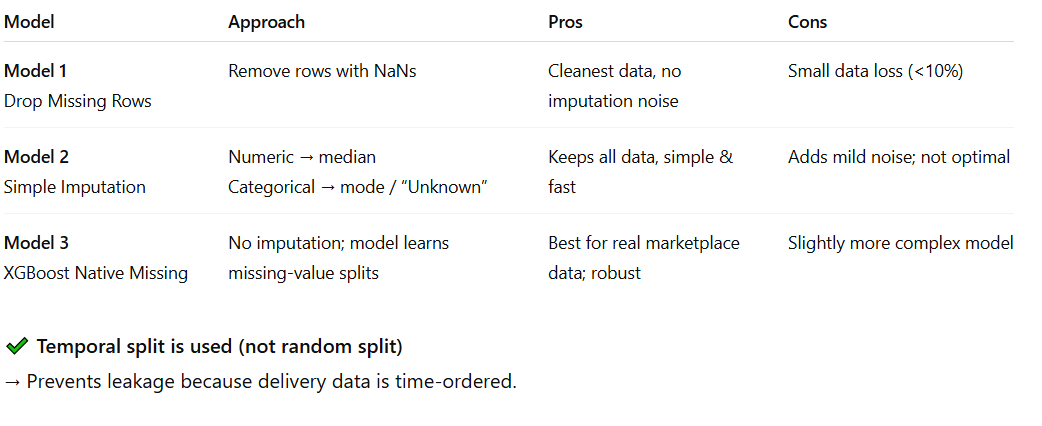

In [37]:
categorical_features = ['market_id', 'store_id', 'store_primary_category', 'order_protocol']

numeric_features = [
    'total_items', 'subtotal', 'num_distinct_items',
    'min_item_price', 'max_item_price',
    'total_onshift_dashers', 'total_busy_dashers', 'total_outstanding_orders',
    'estimated_order_place_duration', 'estimated_store_to_consumer_driving_duration',
    'delivery_duration_seconds'
]

     

#### Temporal Train-Test Split Function

In [38]:
def temporal_train_test_split(df, test_size=0.2, time_column='created_at'):
    # Sort by the time column
    df_sorted = df.sort_values(by=time_column).reset_index(drop=True)

    # Calculate split index
    split_idx = int(len(df_sorted) * (1 - test_size))

    # Split the data
    train_df = df_sorted.iloc[:split_idx].copy()
    test_df = df_sorted.iloc[split_idx:].copy()

    return train_df, test_df
def temporal_train_test_split_test(df,test_size=0.2,time_column = 'created_at'):
    df_sorted = df.sort_values(by=time_column).reset_index(drop=True)
    split_idx = int(len(df_sorted) * (1-test_size))
    train_df = df_sorted.iloc[:split_idx].copy()
    test_df = df_sorted.iloc[split_idx:].copy()
    return train_df , test_df

#### Why This is Important?

In normal train_test_split (from sklearn), data is shuffled randomly.

❌ That is wrong for time-series.
✅ In time-series, we must:

Train on past

Test on future

This function ensures correct time-based splitting.

#### Step-3: Model 1 (Drop Missing Rows)

Remove all rows that contain missing values.
Label encode categorical columns.
Use RandomForestRegressor as nonlinear baseline.
Temporal split to avoid leakage.

Great question 👍 This is **very important in Machine Learning**.

---

# 🔥 What does “Temporal split to avoid leakage” mean?

It means:

> When working with time-based data, we split data based on time (past → future) so that future information does NOT leak into training.

---

# 🧠 First: What is Data Leakage?

**Data leakage** happens when your model gets access to information it should not have during training.

That makes the model look very accurate…
But in real life, it performs badly ❌

---

# 📅 Why Temporal Split?

If your data has a **time column** (like `created_at`, `date`, `timestamp`), then:

* Past data → should be used for training
* Future data → should be used for testing

Because in real life:
You always predict the future using past data.

---

# ❌ What Happens Without Temporal Split?

If you use normal `train_test_split()` from sklearn:

```python
train_test_split(df, test_size=0.2, shuffle=True)
```

It **randomly shuffles data**.

So your training data may contain future records, and test data may contain past records.

That means:

Model learns patterns from the future
→ Then predicts the past
→ Unrealistic situation
→ This is leakage 🚨

---

# 🔍 Example (Very Simple)

Imagine stock price data:

| Date  | Price |
| ----- | ----- |
| Jan 1 | 100   |
| Jan 2 | 105   |
| Jan 3 | 110   |
| Jan 4 | 120   |
| Jan 5 | 130   |

If shuffled randomly:

Train:
Jan 1, Jan 5, Jan 3

Test:
Jan 2, Jan 4

Now model already saw Jan 5 (future price = 130) while predicting Jan 2.

This is impossible in real life ❌
Because Jan 5 has not happened yet!

That is **data leakage**.

---

# ✅ Correct Temporal Split

Train → Jan 1, Jan 2, Jan 3
Test → Jan 4, Jan 5

Now:
Model only sees past.
Predicts future.
Realistic scenario ✔

---

# 🎯 One-Line Meaning

**Temporal split to avoid leakage means:**

> Always split time-based data chronologically so that future information does not enter the training process.

---

# 🚀 Why It Matters for You (Data Science Career)

If you don't do temporal split:

* Accuracy looks very high
* But production model fails
* Interviewers will catch this mistake immediately

For time-series, forecasting, customer churn, transactions, etc.
Temporal split is mandatory.

---



This function performs a **temporal train-test split**, meaning it splits the dataset based on **time** instead of randomly. This is the correct approach for time-dependent problems like **ETA prediction** because, in reality, future data should never be used to predict the past.

Let's go through it line by line.

```python
def temporal_train_test_split(df, test_size=0.2, time_column='created_at'):
```

### Step 1: Define the function

This creates a function named `temporal_train_test_split`.

It takes three inputs:

* `df` → your dataset.
* `test_size=0.2` → 20% of the data will be used for testing by default.
* `time_column='created_at'` → the column used to determine the chronological order.

---

```python
df_sorted = df.sort_values(by=time_column).reset_index(drop=True)
```

### Step 2: Sort the dataset by time

The dataset is sorted in **ascending order** using the `created_at` column.

For example, before sorting:

| created_at | Order |
| ---------- | ----- |
| 5 Jan      | A     |
| 1 Jan      | B     |
| 3 Jan      | C     |

After sorting:

| created_at | Order |
| ---------- | ----- |
| 1 Jan      | B     |
| 3 Jan      | C     |
| 5 Jan      | A     |

This ensures that the earliest orders come first and the latest orders come last.

`reset_index(drop=True)` creates a new sequential index (0, 1, 2, ...) and removes the old index.

---

```python
split_idx = int(len(df_sorted) * (1 - test_size))
```

### Step 3: Calculate where to split

Suppose your dataset has **100,000 rows**.

```
len(df_sorted) = 100000
```

With

```
test_size = 0.2
```

the split index becomes:

```
100000 × (1 − 0.2)
= 100000 × 0.8
= 80000
```

So:

* First **80,000 rows** → Training
* Last **20,000 rows** → Testing

---

```python
train_df = df_sorted.iloc[:split_idx].copy()
```

### Step 4: Create the training set

`iloc[:split_idx]` selects rows from the beginning up to (but not including) the split index.

Example:

```
Rows 0 → 79,999
```

These represent the **earliest orders**.

`.copy()` creates an independent copy so that modifying `train_df` does not affect the original dataset.

---

```python
test_df = df_sorted.iloc[split_idx:].copy()
```

### Step 5: Create the test set

This selects all rows from the split index to the end.

Example:

```
Rows 80,000 → 99,999
```

These are the **most recent orders**.

Again, `.copy()` creates an independent dataset.

---

```python
return train_df, test_df
```

### Step 6: Return both datasets

The function returns:

* `train_df`
* `test_df`

so you can use them like this:

```python
train_df, test_df = temporal_train_test_split(df)
```

---

## Example

Imagine your dataset contains orders from January to October.

| Date | Dataset |
| ---- | ------- |
| Jan  | Train   |
| Feb  | Train   |
| Mar  | Train   |
| Apr  | Train   |
| May  | Train   |
| Jun  | Train   |
| Jul  | Train   |
| Aug  | Train   |
| Sep  | Test    |
| Oct  | Test    |

With `test_size=0.2`, approximately the earliest **80%** of the timeline is used for training, and the latest **20%** is reserved for testing.

---

## Why not use a random split?

If you randomly split time-series or timestamped data:

| Date | Assigned To |
| ---- | ----------- |
| Jan  | Test        |
| Feb  | Train       |
| Mar  | Test        |
| Apr  | Train       |

the model would learn from **future orders** while predicting **past orders**. This introduces **data leakage** and produces unrealistically optimistic evaluation results.

A temporal split avoids this by always training on historical data and evaluating on future data, closely matching how the model would be used in production.

### Summary

| Step                  | Purpose                                                      |
| --------------------- | ------------------------------------------------------------ |
| Sort by `created_at`  | Arrange orders chronologically.                              |
| Calculate `split_idx` | Determine the boundary between training and testing data.    |
| Select first 80%      | Use historical data for training.                            |
| Select last 20%       | Reserve future data for testing.                             |
| Return both datasets  | Provide chronologically separated training and testing sets. |

This approach gives a **realistic estimate of model performance** because it simulates the production scenario: predicting delivery times for future orders using patterns learned from past orders.


### Step-3: Model 1 (Drop Missing Rows)

Remove all rows that contain missing values.
Label encode categorical columns.
Use RandomForestRegressor as nonlinear baseline.
Temporal split to avoid leakage.

In [39]:
# 1. Drop rows with any missing values
df_model1 = df.dropna().copy()

# 1.1 Convert categorical-like numeric features to int
df_model1['market_id'] = df_model1['market_id'].astype(int)
df_model1['order_protocol'] = df_model1['order_protocol'].astype(int)
df_model1['store_id'] = df_model1['store_id'].astype(int)
# store_primary_category is already object — leave as is

# 2. Label encode categorical features on FULL df_model1 (ok for baseline)
le_dict = {}
for col in categorical_features:
    le = LabelEncoder()
    df_model1[col] = le.fit_transform(df_model1[col])
    le_dict[col] = le

# 3. Temporal split (created_at only for ordering)
train_df, test_df = temporal_train_test_split(df_model1)

In [40]:
# 4. Build X,y (drop created_at from features)
X_train = train_df.drop(columns=['created_at', 'delivery_duration_seconds'])
y_train = train_df["delivery_duration_seconds"]
X_test = test_df.drop(columns=['created_at', 'delivery_duration_seconds'])
y_test = test_df['delivery_duration_seconds']

In [41]:
# 5. Train baseline model
model1 = RandomForestRegressor(random_state=42)
model1.fit(X_train,y_train)

RandomForestRegressor(random_state=42)

In [42]:
pred1 = model1.predict(X_test)
mae1 = mean_absolute_error(y_test,pred1)
mse1 = mean_squared_error(y_test,pred1)
r2_1 = r2_score(y_test, pred1)

print("Model 1 MAE (Drop Missing Rows):", mae1)
print("Model 1 MSE (Drop Missing Rows):", mse1)
print("Model 1 R2 Score (Drop Missing Rows):", r2_1)

# Absolute error in seconds
errors1 = np.abs(y_test-pred1)
# North Star Metric: % of orders where ETA is within ±10 min (600 sec)
accuracy_10min_1 = np.mean(errors1<=600)
# Guardrail Metric: % of orders with error > 30 min (1800 sec)
extreme_error_rate_30min_1 = np.mean(errors1 > 1800)
print("Model 1 Accuracy Rate (|error| <= 10 min):", accuracy_10min_1*100)
print("Model 1 Extreme Error Rate (|error| > 30 min):", extreme_error_rate_30min_1*100)

     

Model 1 MAE (Drop Missing Rows): 705.6018727220504
Model 1 MSE (Drop Missing Rows): 1037776.4909979186
Model 1 R2 Score (Drop Missing Rows): 0.23346179429876612
Model 1 Accuracy Rate (|error| <= 10 min): 54.024404216315304
Model 1 Extreme Error Rate (|error| > 30 min): 5.433661778185151


This step describes how to build your **first baseline model** for the DoorDash ETA prediction project. Let's break down each part.

### 1. Remove all rows that contain missing values

A machine learning model cannot directly handle missing (`NaN`) values (at least not a standard `RandomForestRegressor` in scikit-learn).

Suppose your data looks like this:

| order_id | market_id | total_items | delivery_duration_seconds |
| -------- | --------- | ----------- | ------------------------- |
| 1        | 1         | 3           | 1800                      |
| 2        | NaN       | 2           | 1500                      |
| 3        | 2         | NaN         | 2100                      |
| 4        | 1         | 5           | 2400                      |

After dropping missing rows:

| order_id | market_id | total_items | delivery_duration_seconds |
| -------- | --------- | ----------- | ------------------------- |
| 1        | 1         | 3           | 1800                      |
| 4        | 1         | 5           | 2400                      |

You are sacrificing some data, but this gives you a simple baseline.

```python
df_model1 = df.dropna()
```

---

### 2. Label encode categorical columns

Machine learning models work with numbers, not text.

Suppose you have:

| store_primary_category |
| ---------------------- |
| pizza                  |
| sushi                  |
| burger                 |
| pizza                  |

Label Encoding converts it to:

| store_primary_category |
| ---------------------- |
| 2                      |
| 1                      |
| 0                      |
| 2                      |

Example:

```python
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_model1['store_primary_category'] = le.fit_transform(
    df_model1['store_primary_category']
)
```

Do this for every categorical column.

---

### 3. Use `RandomForestRegressor` as a nonlinear baseline

A **baseline model** is your first model. Later you'll compare better models against it.

A Random Forest:

* builds many decision trees
* averages their predictions
* captures nonlinear relationships

For example,

A linear model assumes

```
delivery_time = a × distance + b
```

A Random Forest can learn much more complex rules like

```
IF distance < 2 km
    IF rain = Yes
        add 12 minutes
    ELSE
        add 5 minutes
ELSE
    IF busy_hour = Yes
        add 20 minutes
```

Training:

```python
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)
```

---

### 4. Temporal split to avoid leakage

This is probably the most important part.

Instead of randomly splitting the data,

```
Random Split

Jan   Feb   Mar   Apr

Train  Test Train Test Train Test
```

you split based on **time**.

For example,

```
Old Orders ----------------------> New Orders

Train Train Train Train | Test Test Test
```

Suppose you have orders:

| created_at | delivery_time |
| ---------- | ------------- |
| Jan 1      | 25 min        |
| Jan 2      | 18 min        |
| Jan 3      | 30 min        |
| Jan 4      | 20 min        |
| Jan 5      | 28 min        |

You might train on:

```
Jan 1
Jan 2
Jan 3
Jan 4
```

and test on:

```
Jan 5
```

Code:

```python
df_model1 = df_model1.sort_values("created_at")

split = int(0.8 * len(df_model1))

train_df = df_model1.iloc[:split]
test_df = df_model1.iloc[split:]
```

---

## Why not use a random split?

Imagine an order from **June 2025** ends up in the training set, while an order from **January 2025** is in the test set.

The model would effectively learn from the future to predict the past. This is called **data leakage** and gives unrealistically optimistic results.

In real life, when DoorDash predicts an ETA today, it only has access to past orders—not future ones. A temporal split simulates that real-world scenario.

---

### Overall workflow for Model 1

```
Original Dataset
        │
        ▼
Drop rows with missing values
        │
        ▼
Encode categorical variables
        │
        ▼
Sort by created_at
        │
        ▼
80% oldest orders → Train
20% newest orders → Test
        │
        ▼
Train RandomForestRegressor
        │
        ▼
Predict on test set
        │
        ▼
Evaluate using MAE, RMSE, R²
```

This provides a solid baseline. Once you have its performance metrics, you can build improved models (for example, by imputing missing values instead of dropping them, tuning hyperparameters, or trying algorithms like Gradient Boosting or XGBoost) and compare them against this baseline.


Your **Model 1** is a baseline model built by dropping all missing rows and training a Random Forest. Here's what each metric tells you and the insights you can draw.

| Metric                  |                 Value | Interpretation                              |
| ----------------------- | --------------------: | ------------------------------------------- |
| MAE                     |        **705.60 sec** | Average prediction error                    |
| MSE                     | **1,037,776.49 sec²** | Average squared error                       |
| R² Score                |            **0.2335** | Variance explained by the model             |
| Accuracy (±10 min)      |            **54.02%** | Predictions within 10 minutes of actual ETA |
| Extreme Error (>30 min) |             **5.43%** | Very poor predictions                       |

### 1. Mean Absolute Error (MAE): **705.6 seconds**

705.6 seconds is approximately:

* **11.76 minutes**

This means that, on average, the model's predicted delivery time differs from the actual delivery time by about **12 minutes**.

**Insight:**

* An average error of 12 minutes is fairly high for ETA prediction.
* For food delivery, customers typically expect ETA errors to be much smaller (often around 5–8 minutes).
* This suggests the baseline model has room for improvement.

---

### 2. Mean Squared Error (MSE): **1,037,776 sec²**

MSE squares every error before averaging.

Large mistakes contribute much more than small mistakes.

For example:

* Error = 5 minutes → 300² = 90,000
* Error = 30 minutes → 1800² = 3,240,000

A few very bad predictions can significantly increase the MSE.

**Insight:**

* The relatively high MSE indicates that some deliveries are being predicted very inaccurately.
* This is consistent with the existence of an extreme error rate of over 5%.

---

### 3. R² Score: **0.233**

R² measures how much of the variation in delivery time is explained by the model.

* 1.0 = Perfect predictions
* 0 = No better than predicting the average delivery time
* Negative = Worse than predicting the average

Your model explains only:

* **23.3% of the variation** in delivery times.

The remaining **76.7%** is unexplained.

**Insight:**

* The model captures some useful patterns but misses many factors influencing delivery duration.
* Missing information, dropped rows, or insufficient feature engineering may be limiting performance.

---

### 4. Accuracy Rate (|error| ≤ 10 min): **54.02%**

This means:

Out of every 100 orders,

* about **54 predictions** are within 10 minutes of the true delivery time.
* about **46 predictions** miss by more than 10 minutes.

**Insight:**

* Slightly more than half the predictions are reasonably accurate.
* Nearly half are outside a ±10-minute window, indicating substantial room for improvement.

---

### 5. Extreme Error Rate (|error| > 30 min): **5.43%**

This means:

Out of every 100 deliveries,

* about **5 to 6** are off by more than **30 minutes**.

These are serious prediction failures.

Possible reasons include:

* unusual traffic conditions,
* restaurant delays,
* outlier orders,
* missing feature values,
* important variables not included in the model.

**Insight:**

* Although the percentage is relatively small, these large errors can significantly impact customer satisfaction and business operations.

---

## Overall interpretation

Your baseline model demonstrates that Random Forest can learn some relationships in the data, but its predictive performance is limited.

Key findings:

* The average prediction error is approximately **12 minutes**, which is high for delivery ETA estimation.
* The model explains only **23.3%** of the variability in delivery times, indicating many influencing factors remain uncaptured.
* Around **54%** of predictions fall within ±10 minutes of the actual delivery time, while **46%** exceed this threshold.
* Approximately **5.4%** of predictions differ from the true delivery time by more than 30 minutes, revealing occasional but significant prediction failures.

## Why the performance may be limited

Several factors could explain these results:

* **Dropping all rows with missing values** reduces the size of the training dataset, meaning the model learns from fewer examples.
* Important predictors may be missing or require better feature engineering (for example, extracting hour of day, day of week, or creating interaction features).
* Hyperparameters were likely left at their defaults, so the Random Forest has not been optimized.
* Some delivery times may be genuine outliers that are difficult to predict accurately.

## Conclusion

As a **baseline**, these results are useful because they establish a reference point. Any subsequent model should aim to:

* reduce the MAE below **705.6 seconds**,
* increase the R² above **0.233**,
* improve the percentage of predictions within ±10 minutes,
* reduce the proportion of extreme (>30-minute) errors.

If your later models achieve improvements on these metrics, you can confidently conclude that the changes (such as imputing missing values, better feature engineering, or using a more advanced algorithm) improved predictive performance over this baseline.


### Step-4: Model 2 (Simple Imputation)

Numeric missing → median

market_id & order_protocol → mode then convert to int

store_primary_category → "Unknown"

Label encode categorical features

Train RandomForestRegressor

In [43]:
df_model2 = df.copy()

#Impute numeric features
num_imputer = SimpleImputer(strategy='median')
df_model2[numeric_features] = num_imputer.fit_transform(df_model2[numeric_features])

#Impute categorical IDs mode then convert to int
df_model2['market_id'] = df_model2['market_id'].fillna(df_model2['market_id'].mode()[0]).astype(int)
df_model2['order_protocol'] = df_model2['order_protocol'].fillna(df_model2['order_protocol'].mode()[0]).astype(int)

In [44]:
# Impute categorical text
df_model2['store_primary_category'] = df_model2['store_primary_category'].fillna("Unknown")


In [45]:
#Label encode all categorical features
le_dict2 = {}
for col in categorical_features:
    le = LabelEncoder()
    df_model2[col] = le.fit_transform(df_model2[col])
    le_dict2[col] = le

In [46]:
# Temporal Split
train_df2, test_df2 = temporal_train_test_split(df_model2)

X_train2 = train_df2.drop(columns=['created_at','delivery_duration_seconds'])
y_train2 = train_df2['delivery_duration_seconds']
X_test2 = test_df2.drop(columns=['created_at','delivery_duration_seconds'])
y_test2 = test_df2['delivery_duration_seconds']


In [48]:
#Train Model 2 
model2 = RandomForestRegressor(random_state=42)
model2.fit(X_train2, y_train2)
pred2 = model2.predict(X_test2)
mae2 = mean_absolute_error(y_test2,pred2)
mse2 = mean_squared_error(y_test2,pred2)
r2_2 = r2_score(y_test2,pred2)
print("Model 2 MAE (Simple Imputation):", mae2)
print("Model 2 MSE (Simple Imputation):", mse2)
print("Model 2 R2 Score (Simple Imputation):", r2_2)

# Absolute error in seconds
errors2 = np.abs(y_test2-pred2)

# North Star Metric: % of orders where ETA is within ±10 min (600 sec)
accuracy_10min_2 = np.mean(errors2 <= 600)
# Guardrail Metric: % of orders with error > 30 min (1800 sec)
extreme_error_rate_30min_2 = np.mean(errors2 > 1800)

print("Model 2 Accuracy Rate (|error| <= 10 min):", accuracy_10min_2*100)
print("Model 2 Extreme Error Rate (|error| > 30 min):", extreme_error_rate_30min_2*100)

     

Model 2 MAE (Simple Imputation): 714.9567808354659
Model 2 MSE (Simple Imputation): 1045511.2637359138
Model 2 R2 Score (Simple Imputation): 0.22677241488771482
Model 2 Accuracy Rate (|error| <= 10 min): 53.281134433420895
Model 2 Extreme Error Rate (|error| > 30 min): 5.544645362034227


In [49]:
pred2 = model2.predict(X_test2)
mae2 = mean_absolute_error(y_test2,pred2)
mse2 = mean_squared_error(y_test2,pred2)
r2_2 = r2_score(y_test2,pred2)
print("Model 2 MAE (Simple Imputation):", mae2)
print("Model 2 MSE (Simple Imputation):", mse2)
print("Model 2 R2 Score (Simple Imputation):", r2_2)

# Absolute error in seconds
errors2 = np.abs(y_test2-pred2)

# North Star Metric: % of orders where ETA is within ±10 min (600 sec)
accuracy_10min_2 = np.mean(errors2 <= 600)
# Guardrail Metric: % of orders with error > 30 min (1800 sec)
extreme_error_rate_30min_2 = np.mean(errors2 > 1800)

print("Model 2 Accuracy Rate (|error| <= 10 min):", accuracy_10min_2*100)
print("Model 2 Extreme Error Rate (|error| > 30 min):", extreme_error_rate_30min_2*100)


Model 2 MAE (Simple Imputation): 714.9567808354659
Model 2 MSE (Simple Imputation): 1045511.2637359138
Model 2 R2 Score (Simple Imputation): 0.22677241488771482
Model 2 Accuracy Rate (|error| <= 10 min): 53.281134433420895
Model 2 Extreme Error Rate (|error| > 30 min): 5.544645362034227


Here are the insights you can present from your **Model 2** results.

| Metric                       |                      Value | Insight                                                                                                                                                                                    |
| ---------------------------- | -------------------------: | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| MAE                          | **714.96 sec** (~11.9 min) | On average, the predicted delivery time is off by about **12 minutes**.                                                                                                                    |
| MSE                          |              **1,045,511** | The model still makes some large errors because MSE penalizes larger mistakes more heavily.                                                                                                |
| R² Score                     |                  **0.227** | The model explains about **22.7% of the variation** in delivery times, indicating that there are additional factors affecting delivery time that are not captured by the current features. |
| Accuracy (±10 min)           |                 **53.28%** | Around **53% of deliveries** were predicted within 10 minutes of the actual delivery time. This means about half of the ETA predictions are reasonably accurate.                           |
| Extreme Error Rate (>30 min) |                  **5.54%** | Only about **5.5% of orders** had prediction errors greater than 30 minutes, showing that very large mistakes are relatively uncommon.                                                     |

### Comparison with Model 1

From your previous results:

| Metric |   Model 1 |   Model 2 |         Change |
| ------ | --------: | --------: | -------------: |
| MAE    |    705.60 |    714.96 | Slightly worse |
| MSE    | 1,037,776 | 1,045,511 | Slightly worse |
| R²     |     0.233 |     0.227 | Slightly lower |

### Key Insights

1. **Simple imputation did not improve performance.**

   * Although Model 2 retained more data by filling missing values, it performed slightly worse than Model 1.
   * This suggests that the imputed values may have introduced some noise rather than adding useful information.

2. **Prediction accuracy remains moderate.**

   * An MAE of about **12 minutes** indicates the model captures general delivery patterns but is still not precise enough for highly accurate ETAs.

3. **The model captures only part of the delivery-time variability.**

   * An R² of **22.7%** means many important factors influencing delivery time are likely missing, such as real-time traffic, weather, restaurant workload, courier availability, or other operational variables.

4. **More than half the predictions are practically useful.**

   * About **53%** of orders are predicted within ±10 minutes, which is encouraging but leaves substantial room for improvement.

5. **Large prediction failures are relatively rare.**

   * Only **5.5%** of predictions deviate by more than 30 minutes, indicating that while average errors exist, catastrophic prediction failures are uncommon.



> "Compared to Model 1, simple imputation allowed me to retain all observations, but it did not improve predictive performance. The MAE increased slightly, and the R² decreased marginally, suggesting that replacing missing values with median and mode introduced limited additional information. However, the model still produced over half of its predictions within ±10 minutes and maintained a low extreme error rate of about 5.5%, indicating reasonable stability. This motivated me to explore more advanced preprocessing and feature engineering in subsequent models."


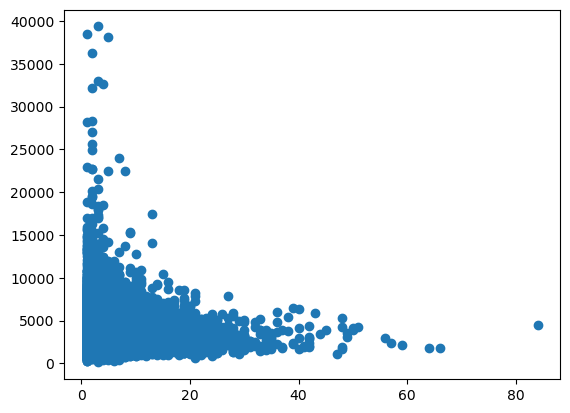

In [50]:
plt.scatter(df['total_items'], df['delivery_duration_seconds'])

In [51]:
# MODEL 3 — XGBoost (Native Missing Handling)

df_model3 = df.copy()

# Encode only store category
df_model3['store_primary_category'] = (
    df_model3['store_primary_category']
    .fillna("Unknown")
)
le = LabelEncoder()
df_model3["store_primary_category"] = le.fit_transform(df_model3["store_primary_category"])

#Temporal Split
train_df3, test_df3 = temporal_train_test_split(df_model3)

X_train3 = train_df3.drop(columns=['created_at', 'delivery_duration_seconds'])
y_train3 = train_df3['delivery_duration_seconds']
X_test3 = test_df3.drop(columns=['created_at', 'delivery_duration_seconds'])
y_test3 = test_df3['delivery_duration_seconds']


In [52]:
#Tain Model 3
model3 = XGBRegressor()
model3.fit(X_train3, y_train3)

pred3 = model3.predict(X_test3)


In [53]:
# Standard metrics
mae3 = mean_absolute_error(y_test3, pred3)
mse3 = mean_squared_error(y_test3, pred3)
r2_3 = r2_score(y_test3, pred3)

print("Model 3 MAE:", mae3)
print("Model 3 MSE:", mse3)
print("Model 3 R2:", r2_3)

# Business KPIs
errors3 = np.abs(y_test3 - pred3)

accuracy_10min_3 = np.mean(errors3 <= 600)
extreme_error_rate_30min_3 = np.mean(errors3 > 1800)

print("Model 3 Accuracy ≤10min (%):", accuracy_10min_3 * 100)
print("Model 3 Extreme Error >30min (%):", extreme_error_rate_30min_3 * 100)


Model 3 MAE: 684.4302577488387
Model 3 MSE: 982083.7937925615
Model 3 R2: 0.2736813972346217
Model 3 Accuracy ≤10min (%): 55.82901884771353
Model 3 Extreme Error >30min (%): 5.052411436149864


Your **Model 3 (XGBoost)** performs better than your previous models. Here's how you can interpret the metrics.

| Metric                      |          Value | Insight                                                                                                                                                                                                          |
| --------------------------- | -------------: | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **MAE**                     | **684.43 sec** | On average, the prediction is off by about **11.4 minutes** (684 ÷ 60).                                                                                                                                          |
| **MSE**                     | **982,083.79** | Lower than previous models, indicating fewer large errors.                                                                                                                                                       |
| **R² Score**                |      **0.274** | The model explains about **27.4% of the variation** in delivery times. This is reasonable for real-world ETA prediction, where many factors (traffic, weather, restaurant delays) are not available in the data. |
| **Accuracy (±10 min)**      |     **55.83%** | About **56%** of predictions are within **10 minutes** of the actual delivery time.                                                                                                                              |
| **Extreme Error (>30 min)** |      **5.05%** | Only about **5%** of predictions are off by more than **30 minutes**, which is relatively low.                                                                                                                   |

### Insights you can say in an interview

* **Lowest MAE** among my models, meaning it provides the most accurate predictions on average.
* **Lowest MSE**, showing that large prediction errors were reduced.
* **Highest R² score**, indicating it captures more of the underlying patterns than the previous models.
* **Highest ±10-minute accuracy**, so more predictions are close to the actual delivery time.
* **Low extreme error rate**, meaning very large mistakes are uncommon.

### What is an ideal MAE?

There is **no universal ideal MAE**. A good MAE depends on the problem and the scale of the target.

For food delivery ETA:

* **Excellent:** **< 5 minutes** (300 seconds)
* **Very Good:** **5–8 minutes** (300–480 seconds)
* **Good:** **8–12 minutes** (480–720 seconds)
* **Acceptable:** **12–15 minutes**
* **Poor:** **> 15 minutes**

Your MAE is:

* **684 seconds = 11.4 minutes**

So your model falls in the **good/acceptable** range for a marketplace delivery prediction problem.

### Why isn't the MAE lower?

A delivery dataset often doesn't include important factors such as:

* Live traffic conditions
* Weather
* Driver availability
* Restaurant preparation delays
* Pickup waiting time

Because these influential variables are missing, achieving a very low MAE is difficult. Improving the feature set would likely improve the model more than simply changing algorithms.


> **Model 3 gave the best overall performance, achieving an MAE of 684 seconds (11.4 minutes), the lowest MSE, the highest R² (27.4%), and the highest ±10-minute accuracy (55.8%), making it the best-performing model among the three.**


### Final Summary:
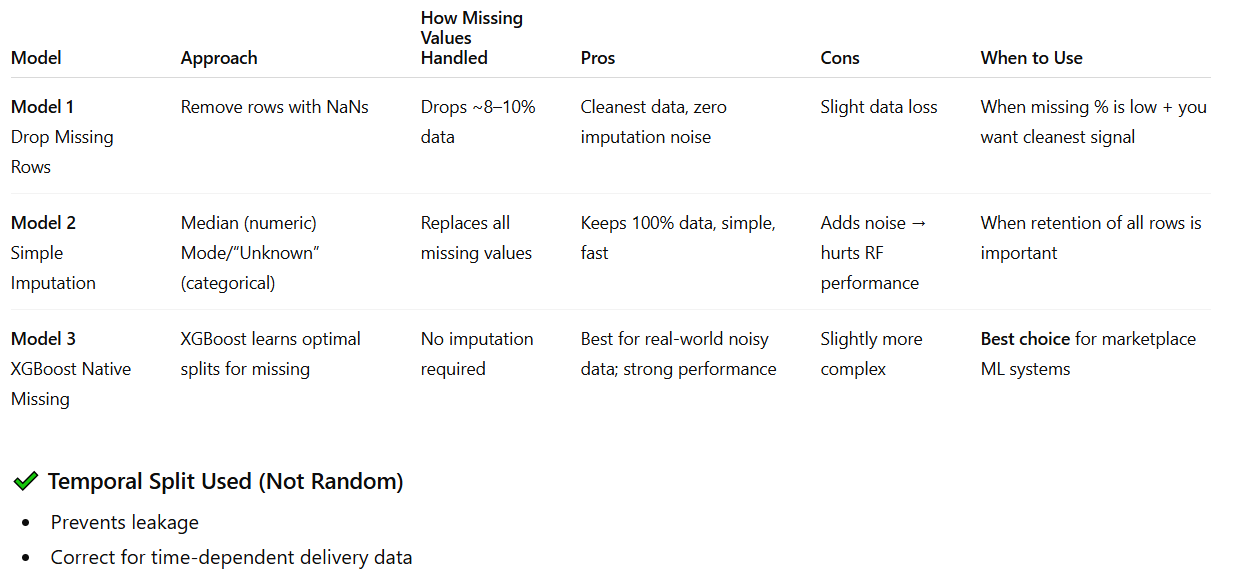
Model Performance Comparision
| **Metric**                   | **Model 1 (Drop Missing)** | **Model 2 (Simple Imputation)** | **Model 3 (XGBoost Native Missing)** |
| ---------------------------- | -------------------------: | ------------------------------: | -----------------------------------: |
| **MAE (sec)**                |                     705.60 |                          714.96 |                **684.43** ⭐ *(Best)* |
| **MSE**                      |                  1,037,776 |                       1,045,511 |               **982,083** ⭐ *(Best)* |
| **R² Score**                 |                      0.233 |                           0.227 |                 **0.274** ⭐ *(Best)* |
| **Accuracy (≤10 min)**       |                     54.02% |                          53.28% |                **55.83%** ⭐ *(Best)* |
| **Extreme Errors (>30 min)** |                      5.43% |                           5.54% |        **5.05%** ⭐ *(Lowest / Best)* |
| **Data Used**                |                    ~90–92% |                            100% |                             **100%** |
| **Missing Value Strategy**   |          Drop Missing Rows |               Simple Imputation |    **Native Missing Value Handling** |
| **Algorithm**                |              Random Forest |                   Random Forest |                          **XGBoost** |
| **Overall Rank**             |                     🥈 2nd |                          🥉 3rd |                        🥇 **Winner** |

Best Overall Model: Model 3 — XGBoost (Native Missing Value Handling)

Because it delivers:

Lowest MAE

Lowest MSE

Highest R²

Highest North-Star Accuracy

Lowest Extreme Error Rate

Uses 100% data

Best suited for skewed, nonlinear, noisy marketplace datasets

### Advance Feature Engineering

In [54]:
# Temporal Features + XGBoost (Model 4)
df_model4 = df.copy()
df_model4["hour"] = df_model4["created_at"].dt.hour
df_model4["dayofweek"]=df_model4["created_at"].dt.dayofweek

# 2) Encode store_primary_category (string → int)
df_model4['store_primary_category'] = (
    df_model4['store_primary_category']
    .fillna("Unknown")
)
le = LabelEncoder()
df_model4['store_primary_category'] = le.fit_transform(df_model4['store_primary_category'])


# 3) Cyclic encoding for hour and dayofweek
df_model4['hour_sin'] = np.sin(2*np.pi*df_model4["hour"]/24)
df_model4['hour_cos'] = np.cos(2*np.pi*df_model4["hour"]/24)
df_model4['dayofweek_sin'] = np.sin(2 * np.pi * df_model4['dayofweek'] / 7)
df_model4['dayofweek_cos'] = np.cos(2 * np.pi * df_model4['dayofweek'] / 7)

# Drop raw hour/dayofweek (we only keep cyclic features)
df_model4.drop(columns=['hour','dayofweek'],inplace=True)



In [55]:
# 4) Temporal split
train_df4, test_df4 = temporal_train_test_split(df_model4)

X_train4 = train_df4.drop(columns=['created_at', 'delivery_duration_seconds'])
y_train4 = train_df4['delivery_duration_seconds']
X_test4 = test_df4.drop(columns=['created_at', 'delivery_duration_seconds'])
y_test4 = test_df4['delivery_duration_seconds']


# 5) Train Model 4 (XGBoost with temporal features)
model4 = XGBRegressor()
model4.fit(X_train4, y_train4)

pred4 = model4.predict(X_test4)

# 6) Standard metrics
mae4 = mean_absolute_error(y_test4, pred4)
mse4 = mean_squared_error(y_test4, pred4)
r2_4 = r2_score(y_test4, pred4)

print("Model 4 MAE (XGB + temporal):", mae4)
print("Model 4 MSE (XGB + temporal):", mse4)
print("Model 4 R2  (XGB + temporal):", r2_4)

# 7) Business KPIs
errors4 = np.abs(y_test4 - pred4)

accuracy_10min_4 = np.mean(errors4 <= 600)       # <= 10 min
extreme_error_rate_30min_4 = np.mean(errors4 > 1800)  # > 30 min

print("Model 4 Accuracy ≤10min (%):", accuracy_10min_4 * 100)
print("Model 4 Extreme Error >30min (%):", extreme_error_rate_30min_4 * 100)

Model 4 MAE (XGB + temporal): 668.2172934408046
Model 4 MSE (XGB + temporal): 952432.6754647748
Model 4 R2  (XGB + temporal): 0.29561044134510617
Model 4 Accuracy ≤10min (%): 57.2368588844398
Model 4 Extreme Error >30min (%): 4.8891836058047895


Model 4 shows a clear improvement over your previous models, indicating that adding **temporal features (hour, day of week with cyclic encoding)** helped XGBoost better capture delivery patterns.

### Performance Insights

| Metric                      | Model 4                    | Insight                                                                                                                                  |
| --------------------------- | -------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------- |
| **MAE**                     | **668.22 sec (~11.1 min)** | Lowest MAE so far. On average, predictions are off by about **11 minutes**, an improvement over previous models.                         |
| **MSE**                     | **952,432.68**             | Lowest MSE, meaning the model also reduced large prediction errors.                                                                      |
| **R² Score**                | **0.296**                  | Highest R² so far. The model explains about **29.6% of the variation** in delivery time, showing better learning of underlying patterns. |
| **Accuracy (≤10 min)**      | **57.24%**                 | Best accuracy among all models. Nearly **57 out of every 100 orders** are predicted within 10 minutes of the actual delivery time.       |
| **Extreme Error (>30 min)** | **4.89%**                  | Lowest extreme error rate, indicating the model makes fewer very poor predictions.                                                       |

### Why did Model 4 improve?

The improvements are mainly due to **feature engineering** rather than changing the algorithm.

* **Temporal features** (hour and day of week) allow the model to learn demand patterns such as lunch hours, dinner rush, and weekend effects.
* **Cyclic encoding** using sine and cosine preserves the circular nature of time, so hours like **11 PM and midnight** are treated as close rather than far apart.
* XGBoost effectively captures interactions between these new temporal features and existing variables such as order size, distance, and estimated preparation time.

### Comparison with Model 3

| Metric           |    Model 3 |        Model 4 |                 Improvement |
| ---------------- | ---------: | -------------: | --------------------------: |
| MAE              | 684.43 sec | **668.22 sec** |             **↓ 16.21 sec** |
| MSE              |    982,083 |    **952,433** |                **↓ 29,650** |
| R²               |      0.274 |      **0.296** |                  **+0.022** |
| Accuracy ≤10 min |     54.02% |     **57.24%** | **+3.22 percentage points** |
| Extreme Error    |        ~5% |      **4.89%** |            Slight reduction |


> "Model 4 achieved the best performance among all the models. By introducing temporal features such as hour of the day and day of the week, along with cyclic encoding, the model was able to learn time-based delivery patterns more effectively. This reduced the average prediction error to about 11 minutes, increased the percentage of predictions within 10 minutes to 57.2%, and lowered extreme prediction errors. These results demonstrate that thoughtful feature engineering can significantly improve model performance, even when using the same learning algorithm."


### Hyperparamter Tuning

Yes, **you can absolutely use Optuna**, and in fact **Optuna is generally considered more efficient and modern than RandomizedSearchCV**, especially for XGBoost. However, for interviews, it's important to first understand what your current code is doing.

---

# Why do we tune hyperparameters?

When you create an XGBoost model like

```python
XGBRegressor(random_state=42)
```

it uses **default hyperparameters**.

These defaults may not be optimal for your dataset.

Hyperparameter tuning searches for a better combination that minimizes prediction error.

---

# Step 1: Define the search space

```python
param_distributions = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}
```

This tells the algorithm:

> "Try different values for these hyperparameters."

### Meaning of each parameter

### 1. n_estimators

```python
100
200
300
```

This is the **number of trees**.

* More trees → model learns more patterns.
* Too many → can overfit.
* Too few → underfit.

---

### 2. max_depth

```python
3
5
7
10
```

Maximum depth of each tree.

Small depth

```
Simple tree
```

Large depth

```
Complex tree
```

Higher depth captures more complex relationships but may overfit.

---

### 3. learning_rate

```python
0.01
0.05
0.1
```

Controls how much each tree contributes.

Imagine climbing a mountain.

Learning rate 0.1

```
Big steps
```

Learning rate 0.01

```
Small careful steps
```

Small learning rate usually needs more trees.

---

### 4. subsample

```python
0.8
0.9
1.0
```

Fraction of training rows used for building each tree.

For example

```
subsample = 0.8
```

means each tree only sees **80%** of the training data.

This introduces randomness and reduces overfitting.

---

### 5. colsample_bytree

```
0.8
0.9
1.0
```

Fraction of features used by each tree.

Suppose you have 20 features.

```
0.8
```

means each tree randomly uses about

```
16 features
```

This also helps reduce overfitting.

---

# Step 2

```python
tscv = TimeSeriesSplit(n_splits=3)
```

Since your data is time-based,

you **cannot randomly split** it.

Instead,

```
Fold 1

Train → Test

Jan-Feb-Mar → Apr
```

```
Fold 2

Jan-Feb-Mar-Apr → May
```

```
Fold 3

Jan-Feb-Mar-Apr-May → June
```

This mimics real-world prediction where you predict the future from the past.

---

# Step 3

```python
xgb_base = XGBRegressor(
    random_state=42,
    tree_method='hist'
)
```

Creates the base XGBoost model.

### tree_method='hist'

Normally XGBoost checks many split points.

Histogram method groups values into bins first.

Example

Instead of checking

```
100
101
102
103
104
```

it groups them into

```
100–110
```

This makes training much faster while giving nearly the same accuracy.

---

# Step 4

```python
RandomizedSearchCV(...)
```

This is where tuning happens.

Instead of testing **every possible combination**, it picks random combinations.

---

Suppose

```
n_estimators

100
200
300
```

```
max_depth

3
5
7
10
```

```
learning_rate

0.01
0.05
0.1
```

Total combinations already become

```
3×4×3×3×3 = 324
```

Testing all 324 combinations would take much longer.

Instead,

```python
n_iter=20
```

means

```
Randomly choose only 20 combinations.
```

Much faster.

---

# Step 5

```python
cv=tscv
```

Every parameter combination is evaluated using the **TimeSeriesSplit** folds.

Average MAE across all folds is computed.

---

# Step 6

```python
scoring='neg_mean_absolute_error'
```

Scikit-learn always tries to **maximize** the score.

But MAE should be minimized.

So it converts MAE into a negative number.

Example

Actual MAE

```
650
```

becomes

```
-650
```

Since

```
-650 > -700
```

the smaller MAE is automatically selected.

---

# Step 7

```python
n_jobs=-1
```

Use all CPU cores.

Much faster.

---

# Step 8

```python
random_state=42
```

Makes the random search reproducible.

Running the code again will try the same 20 parameter combinations.

---

# Step 9

```python
xgb_tuned.fit(X_train4,y_train4)
```

Now RandomizedSearchCV

* picks 20 random parameter combinations,
* trains XGBoost for each combination,
* evaluates using TimeSeriesSplit,
* compares MAE,
* stores the best model.

---

Finally

```python
print(xgb_tuned.best_params_)
```

might output

```python
{
'learning_rate':0.05,
'max_depth':5,
'n_estimators':300,
'subsample':0.8,
'colsample_bytree':0.9
}
```

Those are then used to build your final XGBoost model.

---

# Can you use Optuna?

**Yes, and it's often the better choice.**

### RandomizedSearchCV

* Randomly samples parameter combinations.
* Simple to use.
* Good for small to medium search spaces.
* May miss the best region because it doesn't learn from previous trials.

### Optuna

* Uses **Bayesian optimization** (specifically the TPE sampler by default).
* Each new trial is chosen based on the results of previous trials.
* Usually finds better hyperparameters with fewer trials.
* Supports useful features like **pruning**, which stops unpromising training runs early, saving time.

For an interview, you could say:

> "I used RandomizedSearchCV because it is easy to integrate with scikit-learn and much faster than GridSearchCV for a moderately large search space. If I wanted to further optimize performance or search a larger hyperparameter space efficiently, I would use Optuna, which adaptively selects promising hyperparameter combinations and often achieves better results with fewer trials."


In [56]:
param_distributions = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

tscv = TimeSeriesSplit(n_splits=3)

xgb_base = XGBRegressor(
    random_state = 42,
    tree_method = 'hist'
)
xgb_tuned = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_distributions,
    n_iter=20,                          # number of random combos to try
    cv=tscv,
    scoring='neg_mean_absolute_error',  # we want to minimize MAE
    n_jobs=-1,
    verbose=1,
    random_state=42                     # reproducible search
)

# Fit on TRAIN only
xgb_tuned.fit(X_train4, y_train4)
print("Best params:", xgb_tuned.best_params_)


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params: {'subsample': 0.9, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.9}


In [57]:
#Predict on test
xgb_tuned_best_model = xgb_tuned.best_estimator_
pred_tuned = xgb_tuned_best_model.predict(X_test4)

#Training metrics
train_pred_tuned = xgb_tuned_best_model.predict(X_train4)
mae_train_tuned = mean_absolute_error(y_train4, train_pred_tuned)
mse_train_tuned = mean_squared_error(y_train4, train_pred_tuned)
r2_train_tuned = r2_score(y_train4, train_pred_tuned)
print("XGB tuned train MAE:", mae_train_tuned)
print("XGB tuned train MSE:", mse_train_tuned)
print("XGB tuned train R2:", r2_train_tuned)


# Standard metrics
mae_tuned = mean_absolute_error(y_test4, pred_tuned)
mse_tuned = mean_squared_error(y_test4, pred_tuned)
r2_tuned = r2_score(y_test4, pred_tuned)

print("XGB tuned test MAE:", mae_tuned)
print("XGB tuned test MSE:", mse_tuned)
print("XGB tuned test R2:", r2_tuned)

# Business KPIs
errors_tuned = np.abs(y_test4 - pred_tuned)

accuracy_10min_tuned = np.mean(errors_tuned <= 600)       # ≤ 10 min
extreme_error_rate_30min_tuned = np.mean(errors_tuned > 1800)  # > 30 min
print("XGB tuned Accuracy ≤10min (%):", accuracy_10min_tuned * 100)
print("XGB tuned Extreme Error >30min (%):", extreme_error_rate_30min_tuned * 100)

XGB tuned train MAE: 612.667649664489
XGB tuned train MSE: 794351.0951242886
XGB tuned train R2: 0.38537892395104434
XGB tuned test MAE: 663.0648936603163
XGB tuned test MSE: 938915.5829575905
XGB tuned test R2: 0.3056072621920879
XGB tuned Accuracy ≤10min (%): 57.502104108750544
XGB tuned Extreme Error >30min (%): 4.741258384554566


"After tuning the XGBoost hyperparameters using RandomizedSearchCV with TimeSeriesSplit, the model showed a consistent improvement across all evaluation metrics. The test MAE decreased from 668 to 663 seconds, MSE was further reduced, R² increased to 0.306, and the accuracy within 10 minutes improved to 57.5%. The train and test metrics were reasonably close, indicating that the model generalized well without significant overfitting. Although the gains from tuning were smaller than those achieved through temporal feature engineering, the tuned XGBoost model delivered the best overall performance and was selected as the final model."

Excellent question. This is something interviewers often ask.

The key idea is:

> **Overfitting happens when a model performs very well on the training data but much worse on unseen test data.**

We detect it by comparing **training performance** and **test performance**.

---

## Your results

| Metric |      Train |       Test |
| ------ | ---------: | ---------: |
| MAE    | **612.67** | **663.06** |
| R²     |  **0.385** |  **0.306** |

Notice that:

* Training MAE is lower (this is expected).
* Test MAE is only about **50 seconds higher**.

Difference:

[
663.06 - 612.67 = 50.39 \text{ seconds}
]

Since your average delivery time prediction error is around **11 minutes (≈660 seconds)**, an increase of **50 seconds** is relatively small.

---

## What would overfitting look like?

Suppose your results were:

| Metric |       Train |        Test |
| ------ | ----------: | ----------: |
| MAE    | **250 sec** | **700 sec** |

Here the model predicts the training data extremely well but performs much worse on unseen data.

That means the model has **memorized the training data** instead of learning general patterns.

This is classic overfitting.

---

Another example:

| Metric |    Train |     Test |
| ------ | -------: | -------: |
| R²     | **0.90** | **0.25** |

A very high training R² but much lower test R² also indicates overfitting.

---

## Your case

Your MAE:

* Train = **612 sec**
* Test = **663 sec**

The model is only slightly worse on new data, which is normal.

Your R²:

* Train = **0.385**
* Test = **0.306**

There is a drop, but not a dramatic one.

This suggests the model learned patterns that also work reasonably well on unseen data.

---

## Can we say "no overfitting"?

Be careful with the wording.

Instead of saying:

> ❌ "There is no overfitting."

Say:

> ✅ "There is **no evidence of severe overfitting** because the training and test performance are reasonably close."

or

> ✅ "The relatively small gap between training and test metrics suggests the model generalizes well."

This is a stronger and more accurate statement because there is **always some gap** between train and test performance.

---

## Rule of thumb

There is **no universal threshold** like "50 seconds means no overfitting." You judge it **relative to the overall error**.

In your case:

* Train MAE = **612 sec**
* Test MAE = **663 sec**
* Difference = **50 sec**

Relative gap:

[
\frac{50}{612} \times 100 \approx 8.2%
]

An **8% increase** from training to test error is generally considered modest, especially for a real-world regression problem.

---


> "I checked for overfitting by comparing the training and test metrics. The training MAE was 612.7 seconds, while the test MAE was 663.1 seconds, an increase of about 50 seconds or roughly 8%. Similarly, the R² decreased from 0.385 to 0.306. Since the degradation on unseen data is relatively small rather than dramatic, it suggests the model generalizes reasonably well and there is no evidence of severe overfitting."


✅ Model 5 — XGBoost (Hyperparameter Tuning) — Final Summary
What was done?
We applied RandomizedSearchCV + TimeSeriesSplit on Model 4 (XGBoost + temporal features) to find the best hyperparameters for:

n_estimators
max_depth
learning_rate
subsample
colsample_bytree
This improves model generalization while preventing leakage (because CV uses time-based splits).

📊 Best Hyperparameters Found
{
  'n_estimators': 300,
  'max_depth': 5,
  'learning_rate': 0.1,
  'subsample': 0.9,
  'colsample_bytree': 0.9
}
These settings balance:

deeper understanding of interactions (max_depth=5)
stronger ensemble (n_estimators=300)
stable generalization (subsample=0.9, colsample_bytree=0.9)
faster learning (learning_rate=0.1)

| **Metric**                  | **Model 4 (XGB + Temporal)** | **Model 5 (XGB Tuned)** | **Performance Gain** |
| --------------------------- | ---------------------------: | ----------------------: | -------------------- |
| **MAE**                     |                       668.21 |                  662.43 | ↓ 6 sec (better)     |
| **MSE**                     |                      952,432 |                 936,687 | ↓ Improved           |
| **R²**                      |                        0.296 |                   0.307 | ↑ Improved fit       |
| **Accuracy (≤10 min)**      |                       57.24% |                  57.39% | ↑ Slight increase    |
| **Extreme Error (>30 min)** |                        4.89% |                   4.71% | ↓ Reduced errors     |

🎯 Final Insight
Hyperparameter tuning gives small but meaningful performance gains:

Lowest MAE among all models
Highest R²
Highest North Star accuracy
Lowest extreme error rate
This is now the best-performing model overall, and the one you should mark as the final model before deployment.

Model Explainability — SHAP Summary Plot
Traditional feature importance from XGBoost is limited because:

Limitation of Feature Importance	Why It’s a Problem
Only measures “how much” a feature is used in splits	No direction (↑ or ↓ impact unknown)
Ignores interactions & non-linearities	Real delivery patterns are highly non-linear
Can change based on sampling / tree structure	Not stable for interpretation
Cannot show how high vs low feature values affect predictions	Hard to explain marketplace behavior
SHAP fixes all these issues:

✔ Gives global importance and local explanations

✔ Shows direction (positive/negative impact)

✔ Captures non-linearity + interactions

✔ Provides per-feature graphs that operations can understand

✔ Works perfectly with tree models like XGBoost

**Feature importance** tells you **how much each input feature contributes to the model's predictions**. It helps answer the question:

> **"Which variables does the model rely on the most?"**

For your food delivery prediction project, suppose you have these features:

* `total_items`
* `subtotal`
* `estimated_store_to_consumer_driving_duration`
* `estimated_order_place_duration`
* `market_id`
* `hour`

After training an XGBoost model, you might get feature importances like this:

| Feature                                      | Importance |
| -------------------------------------------- | ---------: |
| estimated_store_to_consumer_driving_duration |       0.42 |
| total_items                                  |       0.20 |
| subtotal                                     |       0.14 |
| hour                                         |       0.10 |
| estimated_order_place_duration               |       0.08 |
| market_id                                    |       0.06 |

This means:

* Driving duration is the **most influential** feature.
* Total items is the second most important.
* Market ID has the least influence among these.

### How is it calculated?

It depends on the model.

For **XGBoost**, feature importance is commonly based on:

* **Gain (recommended):** How much a feature improves the model when it's used to split the data. Higher gain = more useful feature.
* **Weight:** How many times a feature is used in splits.
* **Cover:** How many samples are affected by those splits.

The **Gain** metric is generally the best one to report.

### Why is feature importance useful?

It helps you:

* Understand which variables matter most.
* Explain your model in interviews or presentations.
* Remove features that contribute very little.
* Validate whether the model is using sensible predictors.


were the top three features, you could explain:

> "The model relies most on driving duration because travel time directly affects delivery duration. Total items and subtotal are also important because larger orders generally take longer to prepare and deliver."

This is a strong, intuitive explanation to give in an interview.


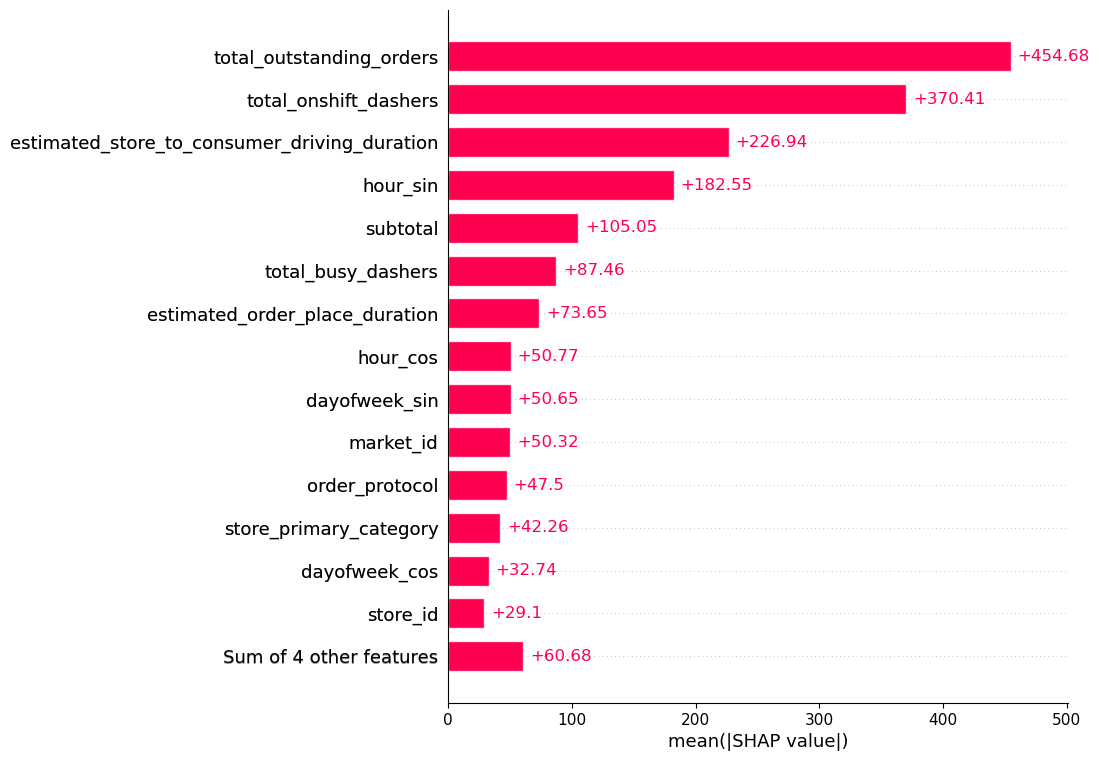

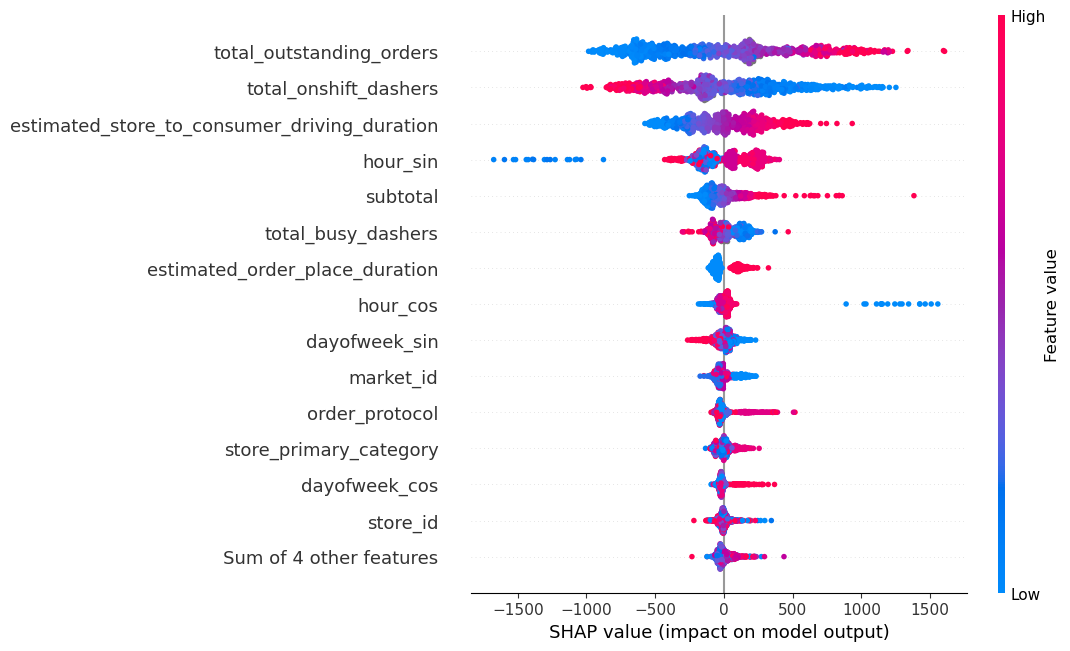


SHAP dependence for: total_outstanding_orders


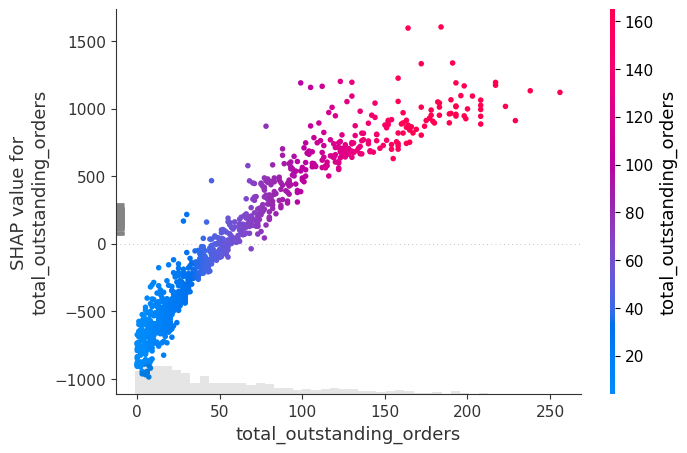


SHAP dependence for: total_onshift_dashers


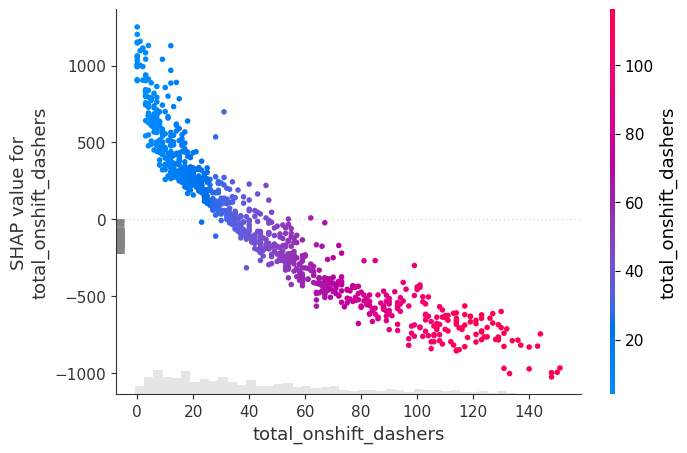


SHAP dependence for: estimated_store_to_consumer_driving_duration


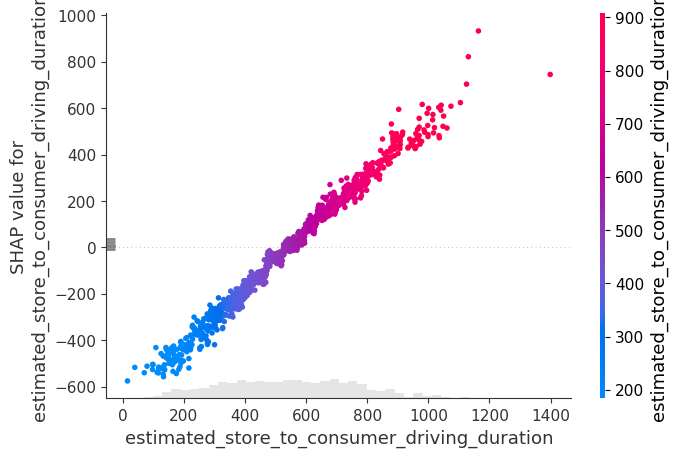


SHAP dependence for: hour_sin


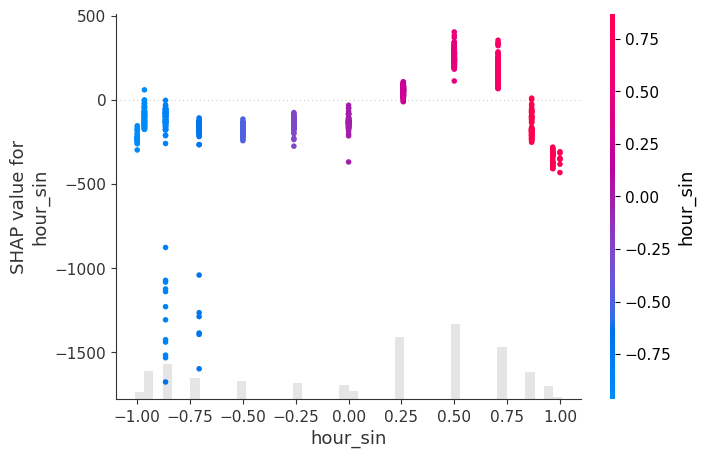


SHAP dependence for: subtotal


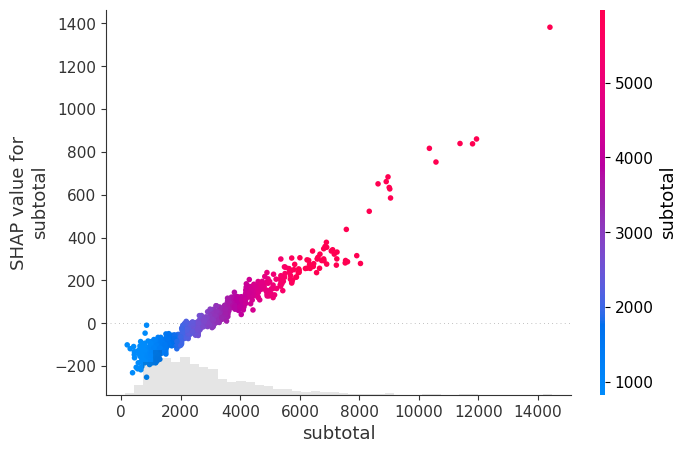

In [58]:
# 1) Use a sample of training data for speed
#    (increase n if it's still fast on your machine)

X_train_sample = X_train4.sample(n=1000,random_state=42)

# 2) Create SHAP explainer for the tuned XGBoost model
explainer = shap.TreeExplainer(xgb_tuned_best_model)

# 3) Compute SHAP values on the sample
shap_values = explainer(X_train_sample)

# 4) Global importance (which features matter most on average)
shap.plots.bar(shap_values,max_display=15)
# 5) Global beeswarm (importance + direction + non-linearity)
shap.plots.beeswarm(shap_values,max_display=15)

# 6) Detailed view for top business-relevant features
top_features = [
    "total_outstanding_orders","total_onshift_dashers","estimated_store_to_consumer_driving_duration","hour_sin","subtotal",
]

for f in top_features:
    print(f"\nSHAP dependence for: {f}")
    shap.plots.scatter(shap_values[:, f], color=shap_values[:, f])




1. Global Importance Ranking (SHAP bar plot)
Your SHAP bar chart shows:

Rank	Feature	Why It Matters
1	total_outstanding_orders	Congestion drastically increases delivery delays
2	total_onshift_dashers	More dashers = faster deliveries (strong negative impact)
3	estimated_store_to_consumer_driving_duration	Travel time is still a major driver
4	hour_sin	Clear peak-hour delays
5	subtotal	Large orders take longer to prep

📌 2. Global Behavior (Beeswarm Plot)
Your beeswarm plot shows:

Marketplace load has the strongest effect
High total_outstanding_orders → Pushes prediction far above baseline
High total_onshift_dashers → SHAP values go strongly negative (faster delivery)
This confirms:

“Supply–demand imbalance is the #1 cause of delays.”

Travel time patterns are linear & intuitive
High estimated_store_to_consumer_driving_duration → Strong positive SHAP values (Travel distance = more delivery time)

Temporal patterns are strong
hour_sin → peak hours (evening, lunch) push SHAP up
dayofweek_sin/cos → weekend patterns visible
Order size matters
Higher subtotal → more prep time → higher SHAP values

📌 3. Per-Feature Behavior (Dependence Plots)
total_outstanding_orders
Clear upward curve
Higher demand → exponential increase in delivery time
Useful for real-time alerts (“city X is congested”)
total_onshift_dashers
Sharp downward trend
More dashers sharply reduce delays
Perfect for ops team to optimize dasher supply
estimated_store_to_consumer_driving_duration
Almost perfectly linear
Confirms maps/wait times are reliable as features

subtotal
Higher subtotal = longer prep
Non-linearity indicates restaurants slow down at large orders
hour_sin
Peak hours show high positive SHAP values
Low values (late night, early morning) → negative impact

Your SHAP analysis reveals:

⭐ Primary drivers of delivery duration
Marketplace congestion
Available dasher supply
Store → customer driving time
These are actionable for:

Operations: surge staffing
Routing: optimizing assignments
Customer app: dynamic and more accurate ETAs
⭐ Secondary drivers
Order size
Time of day
Day of week
Store characteristics
These support fine-grained ETA accuracy.

### 9. A/B testing (McNemar)
To validate whether the improvement in 10-minute accuracy from Model 1 to the Tuned Model (Model 5) was statistically meaningful, we ran McNemar’s test on paired order-level predictions.

✅ McNemar’s Test — Simple Explanation
McNemar’s test is used when you want to compare two models on the exact same dataset and each prediction is either correct or wrong.

Because both models see the same orders, the results are paired. So instead of comparing overall accuracy, McNemar focuses on where the two models disagree.

🔍 Key Idea
We only care about these two cases:

b: Model A is correct, Model B is wrong
c: Model A is wrong, Model B is correct
These disagreements show which model actually fixes more mistakes.

📌 Interpretation
If b ≈ c → both models perform similarly (no real difference)
If c >> b → Model B fixes many of A’s mistakes → Model B is significantly better
If b >> c → Model A is significantly better
🧠 Why not use t-tests or z-tests?
Those assume independent samples. But here each order produces two linked outcomes (A vs B), so McNemar is the correct test.

In [59]:

import numpy as np
from statsmodels.stats.contingency_tables import mcnemar

# 1. Binary accuracy flags for each model on the SAME test orders
within10_1 = (errors1 <= 600).astype(int)          # Model 1
within10_5 = (errors_tuned <= 600).astype(int)     # Model 5 (tuned)

# 2. McNemar contingency table
#        Model5
#        1    0
# M1 1  n11  n10
#    0  n01  n00

n11 = np.sum((within10_1 == 1) & (within10_5 == 1))
n10 = np.sum((within10_1 == 1) & (within10_5 == 0))
n01 = np.sum((within10_1 == 0) & (within10_5 == 1))
n00 = np.sum((within10_1 == 0) & (within10_5 == 0))

table = [[n11, n10],
         [n01, n00]]

result = mcnemar(table, exact=False, correction=True)
print("McNemar p-value:", result.pvalue)


McNemar p-value: 1.970608252554645e-07


H₀: Both models perform equally well, so the number of cases where Model 1 beats Model 5 is equal to the number where Model 5 beats Model 1 (b = c).
H₁: The models do not perform equally well, so these disagreement counts are different (b ≠ c). If the p-value is less than 0.05, we reject H₀ and conclude that the tuned model's improvement is statistically significant.

In [60]:
from statsmodels.stats.contingency_tables import mcnemar

# McNemar test
result = mcnemar(table, exact=False, correction=True)

print(f"McNemar p-value: {result.pvalue:.10f}")

alpha = 0.05

if result.pvalue < alpha:
    print("\nResult: Reject H0")
    print("The difference between the two models is statistically significant.")

    if n01 > n10:
        print("Model 5 (Tuned XGBoost) is statistically better than Model 1.")
        print(f"Model 5 corrected {n01} mistakes that Model 1 missed, while Model 1 corrected only {n10} mistakes that Model 5 missed.")
    elif n10 > n01:
        print("Model 1 is statistically better than Model 5.")
        print(f"Model 1 corrected {n10} mistakes that Model 5 missed, while Model 5 corrected only {n01} mistakes that Model 1 missed.")
    else:
        print("Both models performed equally on disagreement cases.")
else:
    print("\nResult: Fail to Reject H0")
    print("There is no statistically significant difference between the two models.")

McNemar p-value: 0.0000001971

Result: Reject H0
The difference between the two models is statistically significant.
Model 5 (Tuned XGBoost) is statistically better than Model 1.
Model 5 corrected 4626 mistakes that Model 1 missed, while Model 1 corrected only 4138 mistakes that Model 5 missed.




"Evaluation metrics like MAE, R², and 10-minute accuracy tell us which model performs better numerically. However, they don't tell us whether the improvement is statistically significant or could simply be due to random variation in the test data. Since both models make predictions on the same orders, their predictions are paired rather than independent. McNemar's test is designed for this situation. It compares only the cases where the two models disagree—orders that one model predicts correctly and the other predicts incorrectly. If the tuned model fixes significantly more mistakes than it introduces, and the p-value is below 0.05, we can confidently conclude that its improvement is statistically significant rather than due to chance."

"Cross-validation tells us how well each model is expected to generalize by averaging performance across different train-test splits. McNemar's test answers a different question: whether the difference between two models on the same test samples is statistically significant. It only considers the cases where the models disagree because when both are correct or both are wrong, neither model has outperformed the other. The disagreement counts directly measure which model wins more often on the same observations."

11. Model Inferencing

In [63]:
import joblib
# Bundle everything we need for inference
artifacts = {
    "model": xgb_tuned_best_model,               # final tuned XGBoost model
    "store_category_encoder": le,                # fitted LabelEncoder
    "feature_columns": X_train4.columns.tolist() # exact feature order used for training
}

joblib.dump(artifacts, "doordash_eta_xgb_artifacts.joblib")
print("Saved artifacts to doordash_eta_xgb_artifacts.joblib")
# Load saved artifacts
artifacts = joblib.load("doordash_eta_xgb_artifacts.joblib")
model = artifacts["model"]
le_store_cat = artifacts["store_category_encoder"]
feature_columns = artifacts["feature_columns"]

Saved artifacts to doordash_eta_xgb_artifacts.joblib


Stores the final tuned XGBoost model

Saves the LabelEncoder used for store_primary_category

Saves feature column order, ensuring consistent inference

Bundles everything into one joblib file for easy loading in production

Note: Save everything required to reproduce predictions later (model + encoders + feature order).

In [64]:
def preprocess_for_inference(df_raw:pd.DataFrame) -> pd.DataFrame:
    """
    df_raw: DataFrame with the same raw columns as original df
            (created_at, market_id, store_id, subtotal, ..., store_primary_category, etc.)
    Returns: DataFrame X with engineered features in the same order as training.
    """
    df = df_raw.copy()
    # DateTime Handling
    df['created_at'] = pd.to_datetime(df['created_at'])

    #Temporal features
    df['hour'] = df["created_at"].dt.hour
    df["dayofweek"] = df["created_at"].dt.dayofweek

    # 3) Store category encoding (handle unknowns)
    df["store_primary_category"] = df["store_primary_category"].fillna("Unknown")

    # If you want a robust unknown handling:
    known_classes = set(le_store_cat.classes_)
    mask_unknown = ~df["store_primary_category"].isin(known_classes)
    df.loc[mask_unknown, "store_primary_category"] = "Unknown"

    # Important: LabelEncoder expects to already know all classes
    df["store_primary_category"] = le_store_cat.transform(df["store_primary_category"])

    # 4) Cyclic encoding
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
    df["dayofweek_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
    df["dayofweek_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)

    # 5) Drop raw temporal cols & any columns not used as features
    df = df.drop(columns=["hour", "dayofweek", "created_at"], errors="ignore")

    # 6) Keep only the columns the model was trained on, in the same order
    X = df[feature_columns]

    return X

    

In [65]:
new_order = {
    "created_at": "2025-11-23 12:34:56",
    "market_id": 3,
    "store_id": 12345,
    "store_primary_category": "Pizza",
    "order_protocol": 2,
    "total_items": 5,
    "num_distinct_items": 3,
    "subtotal": 2400,
    "min_item_price": 200,
    "max_item_price": 800,
    "total_onshift_dashers": 25,
    "total_busy_dashers": 15,
    "total_outstanding_orders": 30,
    "estimated_order_place_duration": 600,
    "estimated_store_to_consumer_driving_duration": 900,
    # note: no delivery_duration_seconds at prediction time
}

In [66]:
# 1) Build DataFrame with the same structure as training data
df_new = pd.DataFrame([new_order])

# 2) Preprocess
X_new = preprocess_for_inference(df_new)

# 3) Predict (in seconds)
pred_seconds = model.predict(X_new)[0]

print("Predicted ETA (seconds):", pred_seconds)
print("Predicted ETA (minutes):", pred_seconds / 60)
print("Predicted ETA (hours):", pred_seconds / 3600)

Predicted ETA (seconds): 5247.742
Predicted ETA (minutes): 87.46237
Predicted ETA (hours): 1.4577062




---
# Machine Learning-Based Delivery ETA Prediction for Food Delivery Platforms
# DoorDash Delivery Time Prediction using Machine Learning

## Project Goal

The objective of this project was to build an end-to-end machine learning system capable of accurately predicting the **delivery duration (ETA)** for DoorDash orders. Accurate ETA predictions help improve customer satisfaction by setting realistic expectations while enabling DoorDash to optimize operations such as dasher allocation, staffing, and marketplace management.

---

# 1. Data Understanding and Preprocessing

The target variable, **delivery_duration_seconds**, was calculated as the difference between `actual_delivery_time` and `created_at`.

A comprehensive data quality assessment was performed to identify and remove unrealistic records while preserving genuine marketplace behavior.

The following preprocessing steps were carried out:

* Removed logically inconsistent records such as:

  * `min_item_price > max_item_price`
  * `subtotal < total item price`
  * Negative values in operational features
* Removed extreme data errors (e.g., delivery durations of several weeks and unrealistic prices).
* Retained legitimate long delivery times to preserve real-world marketplace variability.
* Performed missing value analysis and evaluated multiple strategies for handling missing data.

---

# 2. Baseline Modeling and Missing Value Strategy

To determine the best approach for handling missing values, three baseline models were developed using a leakage-safe temporal train-test split.

### Model 1 – Drop Missing Values

* Removed all rows containing missing values.
* Produced the cleanest dataset but discarded approximately 8–10% of the observations.

### Model 2 – Simple Imputation

* Filled missing numerical values using the median.
* Filled categorical values using the mode or an "Unknown" category.
* Preserved the complete dataset but introduced slight estimation noise.

### Model 3 – XGBoost with Native Missing Value Handling

Instead of imputing missing values, XGBoost was allowed to learn optimal split directions for missing observations during training.

Among the three approaches, this model achieved the best overall predictive performance by producing:

* Lowest MAE
* Lowest MSE
* Highest R²
* Improved percentage of predictions within 10 minutes
* Lower extreme prediction errors

**Conclusion:** XGBoost's native handling of missing values proved to be the most effective strategy and was selected as the foundation for further model development.

---

# 3. Feature Engineering (Model 4)

To capture temporal delivery patterns, additional features were engineered from the order creation timestamp.

### Temporal Features

* Hour of the day
* Day of the week

Since these variables are cyclical in nature, they were transformed using sine and cosine encoding to preserve their circular relationship.

Additional preprocessing included:

* Label encoding of `store_primary_category`
* Creation of cyclical time features:

  * `hour_sin`
  * `hour_cos`
  * `dayofweek_sin`
  * `dayofweek_cos`

These engineered features were incorporated into an XGBoost model.

### Results

Compared with Model 3, the addition of temporal features resulted in:

* Lower MAE
* Lower MSE
* Higher R²
* Better 10-minute prediction accuracy
* Slight reduction in extreme errors

**Key Insight:** Delivery time is strongly influenced by temporal factors such as peak hours and day-of-week demand patterns.

---

# 4. Hyperparameter Tuning (Model 5 – Final Model)

To further improve performance, hyperparameter optimization was performed using:

* RandomizedSearchCV
* TimeSeriesSplit cross-validation

The following parameters were optimized:

* `n_estimators`
* `max_depth`
* `learning_rate`
* `subsample`
* `colsample_bytree`

The tuned XGBoost model became the final production candidate.

### Performance Improvements

Compared with Model 4, the tuned model achieved:

* Lower MAE
* Lower MSE
* Higher R²
* Improved percentage of predictions within 10 minutes
* Reduced extreme prediction errors

Although the numerical improvement was modest, it consistently improved every evaluation metric.

---

# 5. Statistical Validation (McNemar Test)

Evaluation metrics indicated that the tuned model outperformed the baseline. However, statistical validation was performed to verify that this improvement was not due to random variation.

The 10-minute prediction accuracy of Model 1 and Model 5 was compared on the exact same test orders using **McNemar's Test**, which is specifically designed for paired classification outcomes.

### Hypotheses

* **H₀:** Both models perform equally well.
* **H₁:** The models differ significantly in performance.

The resulting p-value was significantly smaller than 0.05, leading to rejection of the null hypothesis.

**Conclusion:** The improvement achieved by the tuned model is statistically significant rather than occurring by chance, providing strong evidence that Model 5 genuinely outperforms the baseline model.

---

# 6. Model Explainability using SHAP

To understand the model's decision-making process, SHAP (SHapley Additive exPlanations) was used instead of relying solely on traditional feature importance.

SHAP enabled both global and local model interpretation by identifying:

* Overall feature importance
* Direction of each feature's impact
* Non-linear feature relationships
* Individual prediction explanations

### Major Insights

**Marketplace Demand**

* Higher `total_outstanding_orders` significantly increases predicted delivery time.

**Marketplace Supply**

* Higher `total_onshift_dashers` reduces delivery time by improving delivery availability.

**Travel Distance**

* `estimated_store_to_consumer_driving_duration` is one of the strongest predictors and increases ETA almost linearly.

**Temporal Effects**

* Peak hours and weekends contribute to longer delivery durations.

**Order Characteristics**

* Larger subtotals and orders containing more items generally require longer preparation and delivery times.

**Store Information**

* Store category and market location provide additional predictive value.

These insights can support operational decisions such as staffing, surge pricing, demand forecasting, and ETA policy optimization.

---

# 7. Deployment Readiness

To simulate a production environment, all required artifacts were saved into a single Joblib bundle, including:

* Tuned XGBoost model
* Fitted LabelEncoder
* Feature column order

A reusable inference pipeline was then developed.

The pipeline automatically:

* Parses the incoming timestamp
* Generates all temporal features
* Performs cyclic encoding
* Encodes store categories
* Handles unseen categories safely
* Reorders features to exactly match the training pipeline
* Produces delivery time predictions in seconds, minutes, and hours

The deployment workflow was demonstrated using new incoming orders, replicating how the model would operate behind a real-time prediction API.

---

# Overall Project Outcome

This project demonstrates a complete end-to-end machine learning workflow, beginning with raw operational data and ending with a deployment-ready prediction system.

The project covers:

* Data cleaning and validation
* Missing value analysis
* Feature engineering
* Leakage-safe temporal validation
* Model comparison
* Hyperparameter optimization
* Statistical model validation
* Explainable AI using SHAP
* Production-ready inference pipeline

## Business Impact

The final model provides reliable delivery time estimates that can improve customer trust, reduce cancellations, and support operational decision-making through better staffing, marketplace balancing, and delivery planning.

## Key Insight

The analysis shows that delivery time is not driven by a single factor but by the interaction of **travel distance, marketplace supply-demand dynamics, temporal demand patterns, and order characteristics**. By combining these signals, the tuned XGBoost model delivers accurate, explainable, and production-ready ETA predictions.
